In [54]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns #type: ignore
import os
import json

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import pandas as pd
import pickle
from datetime import datetime
import warnings
import traceback

import xgboost as xgb #type: ignore
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from datetime import timedelta


warnings.filterwarnings('ignore')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [4]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

In [5]:
def append_to_json_file(data, file):
    if os.path.exists(file):
        return 
    
    with open(file, 'w', encoding='utf-8') as json_file:
        json.dump(data, json_file, indent=4, ensure_ascii=False)
    print(f"Data saved to {file}")


def preprocess_for_forecasting(df):
    """
    Preprocesses the DataFrame for time series forecasting.
    """

    df_processed = df.copy()

    df_processed['date'] = pd.to_datetime(df_processed['date'])

    df_processed.set_index('date', inplace=True)

    df_processed.sort_index(inplace=True)

    numeric_cols = df_processed.select_dtypes(include=['float64', 'int64']).columns
    df_processed[numeric_cols] = df_processed[numeric_cols].interpolate(method='time')

    df_processed['dayofweek'] = df_processed.index.dayofweek
    df_processed['month'] = df_processed.index.month
    df_processed['year'] = df_processed.index.year
    df_processed['dayofyear'] = df_processed.index.dayofyear
    df_processed['weekofyear'] = df_processed.index.isocalendar().week.astype(int)

    for col in ['total_price_167', 'taux_occupation_167', 'total_price_166', 'taux_occupation_166']:
        if col in df_processed.columns:
            df_processed[col] = pd.to_numeric(df_processed[col], errors='coerce') 

    if df_processed.isnull().sum().sum() > 0:
        print("Warning: NaNs still present after interpolation. Consider further handling (e.g., ffill/bfill).")
        df_processed.ffill(inplace=True)

    return df_processed

In [6]:
df = pd.read_csv('../../Data/UnitsFinalCSVData/FinalCSVdata.csv')
df.head()

,date,total_price_166,taux_occupation_166,total_price_167,taux_occupation_167
0,2024-01-01,9416.0,0.0,6692.25,0.0
1,2024-01-02,9416.0,0.0,6692.25,0.0
2,2024-01-03,9416.0,0.0,6692.25,0.0
3,2024-01-04,7308.0,0.0,7176.00,0.0
4,2024-01-05,7308.0,0.0,7176.00,0.0


In [7]:
df = preprocess_for_forecasting(df)
df.head()

,total_price_166,taux_occupation_166,total_price_167,taux_occupation_167,dayofweek,month,year,dayofyear,weekofyear
date,,,,,,,,,
2024-01-01,9416.0,0.0,6692.25,0.0,0,1,2024,1,1
2024-01-02,9416.0,0.0,6692.25,0.0,1,1,2024,2,1
2024-01-03,9416.0,0.0,6692.25,0.0,2,1,2024,3,1
2024-01-04,7308.0,0.0,7176.00,0.0,3,1,2024,4,1
2024-01-05,7308.0,0.0,7176.00,0.0,4,1,2024,5,1


<Axes: title={'center': 'Total Price Over Time'}, xlabel='date'>

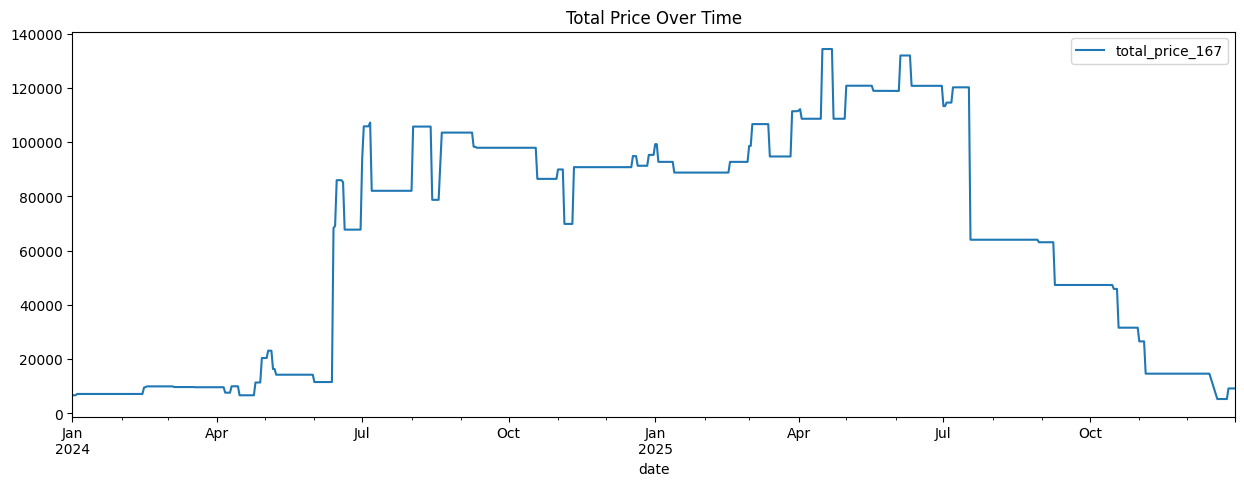

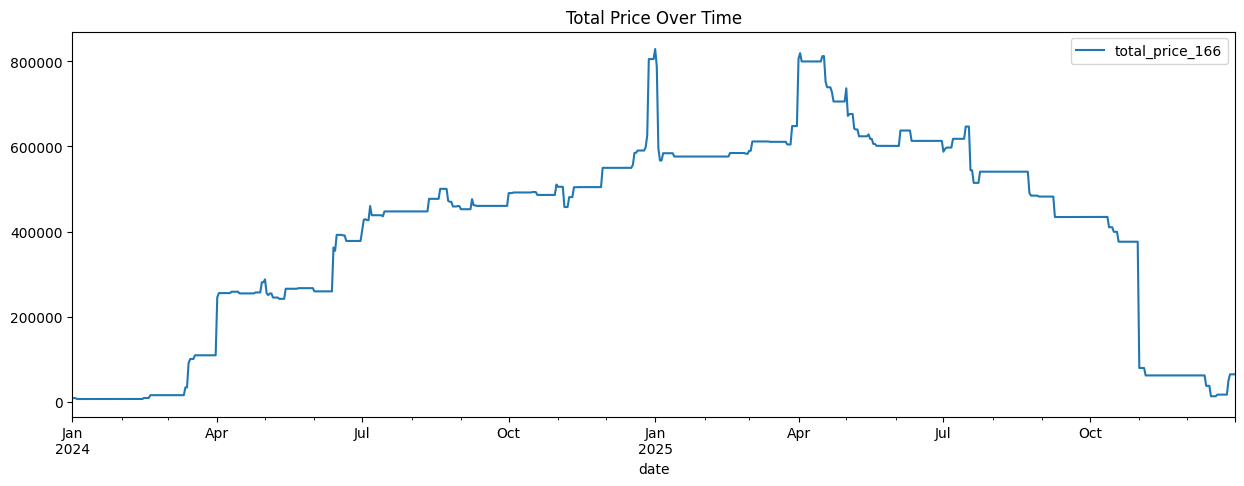

In [8]:
df.plot(figsize=(15, 5), title='Total Price Over Time', y='total_price_167')
df.plot(figsize=(15, 5), title='Total Price Over Time', y='total_price_166')

<Axes: title={'center': 'TAUX Over Time'}, xlabel='date'>

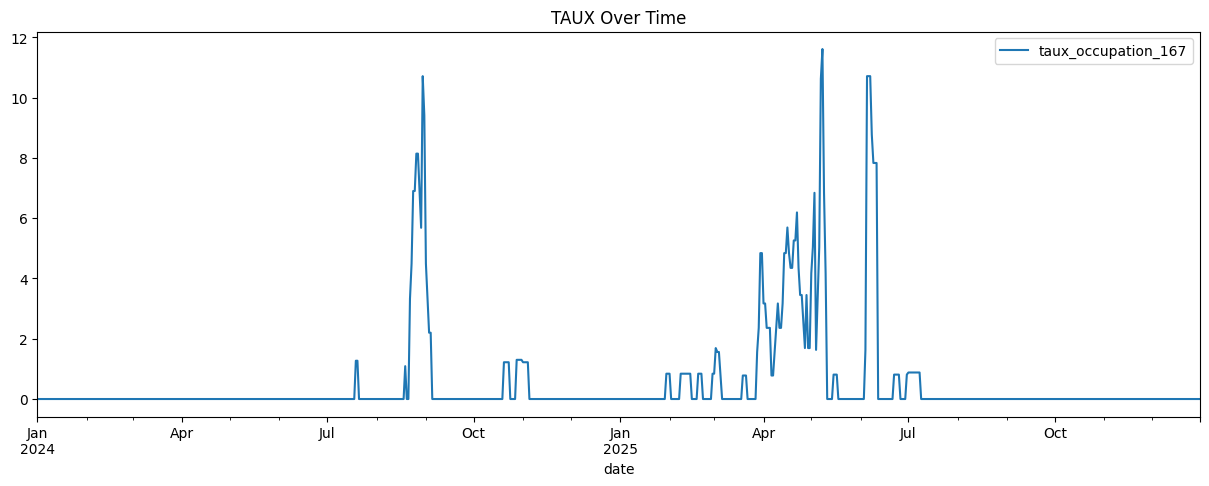

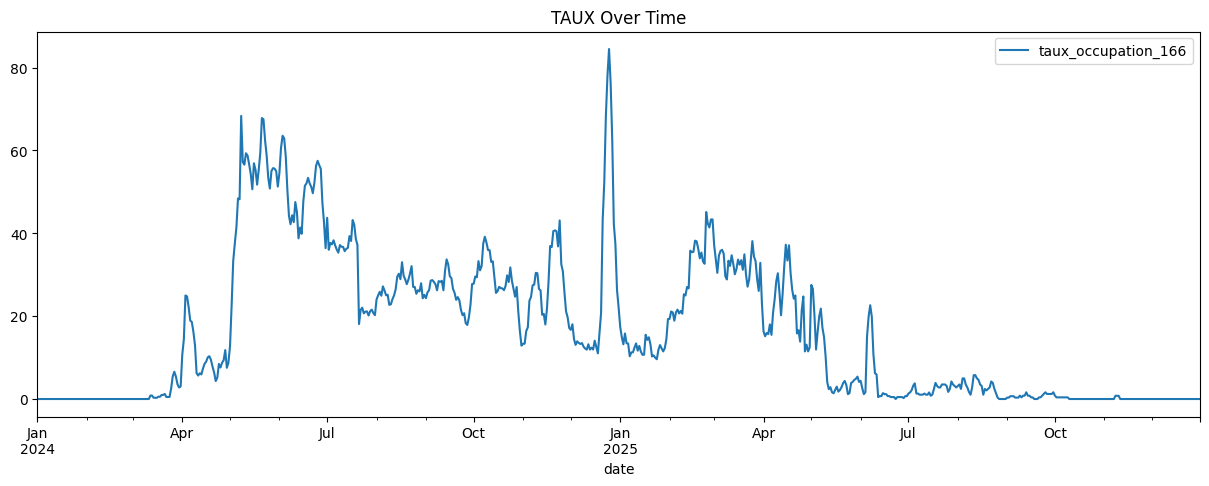

In [9]:
df.plot(figsize=(15, 5), title='TAUX Over Time', y='taux_occupation_167')
df.plot(figsize=(15, 5), title='TAUX Over Time', y='taux_occupation_166')

In [10]:
def select_date_range(df, start_date, end_date): 
    """
    Selects a date range from the DataFrame.
    """
    start = pd.to_datetime(start_date)
    end = pd.to_datetime(end_date)
    
    df_range = df.loc[start:end]
    
    return df_range

In [11]:
df1 = select_date_range(df, '2024-06-15', '2025-07-15')

In [12]:
def split_df(df, units=['167', '166']):
    """
    Splits the DataFrame based on the units.
    """
    common_cols = ['dayofweek', 'month', 'year', 'dayofyear', 'weekofyear']
    
    if 'date' not in df.columns and df.index.name == 'date':
        df = df.reset_index()
    
    if 'date' in df.columns:
        common_cols = ['date'] + common_cols
    
    df_167 = df[common_cols + [f'total_price_{units[0]}', f'taux_occupation_{units[0]}']]
    
    df_166 = df[common_cols + [f'total_price_{units[1]}', f'taux_occupation_{units[1]}']]

    df_166.set_index('date', inplace=True)
    df_167.set_index('date', inplace=True)
    
    return df_167, df_166

In [13]:
df_167, df_166 = split_df(df1, units=['167', '166'])

In [14]:
df_166

,dayofweek,month,year,dayofyear,weekofyear,total_price_166,taux_occupation_166
date,,,,,,,
2024-06-15,5,6,2024,167,24,392553.004,39.89
2024-06-16,6,6,2024,168,24,392553.004,47.59
2024-06-17,0,6,2024,169,25,392553.004,51.48
2024-06-18,1,6,2024,170,25,392553.004,52.04
2024-06-19,2,6,2024,171,25,391309.004,53.39
...,...,...,...,...,...,...,...
2025-07-11,4,7,2025,192,28,618033.926,1.32
2025-07-12,5,7,2025,193,28,618033.926,1.05
2025-07-13,6,7,2025,194,28,618033.926,1.05


### Train the `regression Model`

In [15]:
def split_df(df, units=['167', '166']):
    """
    Splits the DataFrame based on the units.
    """
    common_cols = ['dayofweek', 'month', 'year', 'dayofyear', 'weekofyear']
    
    if 'date' not in df.columns and df.index.name == 'date':
        df = df.reset_index()
    
    if 'date' in df.columns:
        common_cols = ['date'] + common_cols
    
    df_167 = df[common_cols + [f'total_price_{units[0]}', f'taux_occupation_{units[0]}']]
    
    df_166 = df[common_cols + [f'total_price_{units[1]}', f'taux_occupation_{units[1]}']]

    df_166.set_index('date', inplace=True)
    df_167.set_index('date', inplace=True)
    
    return df_167, df_166

def split_data_train_test(df, unit_id, test_size=0.2):
    """
    Splits the DataFrame chronologically into training and testing sets.
    """
    df_copy = df.copy()

    if df_copy.index.name == 'date':
        df_copy = df_copy.sort_index()
    
    elif 'date' in df_copy.columns:
        df_copy = df_copy.sort_values('date').reset_index(drop=True)
    
    else:
        print("Warning: No 'date' index or column found. Assuming index is chronological.")
        df_copy = df_copy.sort_index()
        if df_copy.index.name == 'date':
             df_copy = df_copy.reset_index()


    target_col = f'total_price_{unit_id}'
    if target_col not in df_copy.columns:
        raise ValueError(f"Target column '{target_col}' not found in DataFrame.")

    X = df_copy.drop([target_col], axis=1, errors='ignore')
    y = df_copy[target_col]

    split_idx = int(len(df_copy) * (1 - test_size))
    if split_idx == 0 or split_idx >= len(df_copy):
        raise ValueError("test_size results in an invalid split index.")

    X_train = X.iloc[:split_idx]
    X_test = X.iloc[split_idx:]
    y_train = y.iloc[:split_idx]
    y_test = y.iloc[split_idx:]

    date_col_in_features = 'date' in X_train.columns
    if date_col_in_features:
        X_train = X_train.drop('date', axis=1, errors='ignore')
        X_test = X_test.drop('date', axis=1, errors='ignore')

    print(f"split complete. Test size: {test_size:.2f}")
    print(f"Training set range: {X_train.index.min()} to {X_train.index.max()} ({len(X_train)} samples)")
    print(f"Testing set range: {X_test.index.min()} to {X_test.index.max()} ({len(X_test)} samples)")

    return X_train, X_test, y_train, y_test, target_col


def train_evaluate_linear_model(X_train, X_test, y_train, y_test, target_col):
    """
    Trains a Linear Regression model, evaluates it, and returns results.
    """
    print(f"\nTraining Linear Regression model for target: {target_col}")
    print(f"Features used (X): {X_train.columns.tolist()}")
    print(f"Training set size: {X_train.shape[0]} samples")
    print(f"Testing set size: {X_test.shape[0]} samples")

    model = LinearRegression()
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    train_mae = mean_absolute_error(y_train, y_train_pred)
    test_mae = mean_absolute_error(y_test, y_test_pred)
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)

    print("\nModel Evaluation Metrics:")
    print(f"Train RMSE: {train_rmse:.2f}")
    print(f"Test RMSE: {test_rmse:.2f}")
    print(f"Train MAE: {train_mae:.2f}")
    print(f"Test MAE: {test_mae:.2f}")
    print(f"Train R²: {train_r2:.4f}")
    print(f"Test R²: {test_r2:.4f}")

    feature_importance = pd.DataFrame({
        'Feature': X_train.columns,
        'Coefficient': model.coef_
    }).sort_values('Coefficient', key=abs, ascending=False)

    print("\nFeature Importance (Coefficients):")
    print(feature_importance)

    return {
        'model': model,
        'X_train': X_train,
        'X_test': X_test,
        'y_train': y_train,
        'y_test': y_test,
        'y_train_pred': y_train_pred,
        'y_test_pred': y_test_pred,
        'metrics': {
            'train_rmse': train_rmse,
            'test_rmse': test_rmse,
            'train_mae': train_mae,
            'test_mae': test_mae,
            'train_r2': train_r2,
            'test_r2': test_r2
        },
        'feature_importance': feature_importance
    }


def plot_predictions_over_time(model_results, df, unit_id):
    """
    Plots actual vs. predicted values over time with dates on the x-axis,
    using the indices from the model results for chronological alignment.
    """

    y_train = model_results['y_train']
    y_test = model_results['y_test']
    y_train_pred = model_results['y_train_pred']
    y_test_pred = model_results['y_test_pred']

    train_df = pd.DataFrame({
        'date': y_train.index,  
        'actual': y_train.values,
        'predicted': y_train_pred
    }).sort_values('date')

    test_df = pd.DataFrame({
        'date': y_test.index,   
        'actual': y_test.values,
        'predicted': y_test_pred
    }).sort_values('date')

    fig, axes = plt.subplots(2, 1, figsize=(15, 10), sharex=True)

    axes[0].plot(train_df['date'], train_df['actual'], 'b-', label='Actual Price', alpha=0.7)
    axes[0].plot(train_df['date'], train_df['predicted'], 'r--', label='Predicted Price')
    axes[0].set_title(f'Training Data: Unit {unit_id} - Actual vs Predicted Prices')
    axes[0].set_ylabel('Price')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(test_df['date'], test_df['actual'], 'b-', label='Actual Price', alpha=0.7)
    axes[1].plot(test_df['date'], test_df['predicted'], 'r--', label='Predicted Price')
    axes[1].set_title(f'Test Data: Unit {unit_id} - Actual vs Predicted Prices')
    axes[1].set_xlabel('Date')
    axes[1].set_ylabel('Price')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    fig.autofmt_xdate() 

    plt.tight_layout()
    plt.show()


def plot_actual_vs_predicted(model, df, unit_id):
    """
    Plots the actual vs. predicted values for the entire dataset using a trained model.
    """
    df_copy = df.copy()

    if df_copy.index.name == 'date':
        df_copy = df_copy.sort_index()
    elif 'date' in df_copy.columns:
        df_copy = df_copy.sort_values('date') 
    else:
        print("Warning: DataFrame must have a 'date' index or column for plotting.")
        df_copy = df_copy.sort_index()


    target_col = f'total_price_{unit_id}'
    if target_col not in df_copy.columns:
        print(f"Error: Target column '{target_col}' not found in DataFrame.")
        return

    features = df_copy.drop([target_col], axis=1, errors='ignore')
    if 'date' in features.columns:
         features = features.drop('date', axis=1, errors='ignore') 

    print(f"Columns used for prediction: {features.columns.tolist()}")

    predictions = model.predict(features)

    plot_df = pd.DataFrame({
        'Actual': df_copy[target_col],
        'Predicted': predictions
    })
    plot_df.index = df_copy.index if df_copy.index.name == 'date' else df_copy['date']


    plt.figure(figsize=(15, 7))
    plt.plot(plot_df.index, plot_df['Actual'], 'b-', label='Actual Price', alpha=0.7)
    plt.plot(plot_df.index, plot_df['Predicted'], 'r--', label='Predicted Price')

    plt.title(f'Unit {unit_id}: Actual vs. Predicted Prices (Full Dataset)')
    plt.xlabel('Date')
    plt.ylabel('Price')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [16]:
def run_linear_regression_pipeline(df_unit, unit_id, test_size=0.2):
    """
    Runs the complete Linear Regression training, evaluation, and plotting pipeline
    for a specific unit.

    Args:
        df_unit (pd.DataFrame): The DataFrame containing data for the specific unit.
        unit_id (str): The identifier for the unit (e.g., '166', '167').
        test_size (float): The proportion of the data to use for the test set.

    Returns:
        dict: The results dictionary returned by train_evaluate_linear_model.
    """
    print(f"--- Starting Linear Regression Pipeline for Unit {unit_id} ---")

    print(f"\n[Step 1/3] Splitting data with test_size={test_size}...")
    try:
        X_train, X_test, y_train, y_test, target_col = split_data_train_test(
            df_unit, unit_id, test_size=test_size
        )
    except ValueError as e:
        print(f"Error during data splitting: {e}")
        return None
    except Exception as e:
         print(f"An unexpected error occurred during data splitting: {e}")
         return None

    print("\n[Step 2/3] Training and evaluating Linear Regression model...")
    try:
        model_results = train_evaluate_linear_model(
            X_train, X_test, y_train, y_test, target_col
        )
    except Exception as e:
         print(f"An unexpected error occurred during training/evaluation: {e}")
         return None

    print("\n[Step 3/3] Plotting results...")
    try:
        print("Plotting predictions on train/test split...")
        plot_predictions_over_time(model_results, df_unit, unit_id)

        print("Plotting predictions on the full unit DataFrame...")
        plot_actual_vs_predicted(model_results['model'], df_unit, unit_id)

    except KeyError as e:
        print(f"Error during plotting: Missing key in model_results - {e}")
    except Exception as e:
        print(f"An unexpected error occurred during plotting: {e}")

    print(f"\nPipeline finished for Unit {unit_id}.")
    print("--- End Linear Regression Pipeline ---")

    return model_results

--- Starting Linear Regression Pipeline for Unit 166 ---

[Step 1/3] Splitting data with test_size=0.2...
split complete. Test size: 0.20
Training set range: 2024-06-15 00:00:00 to 2025-04-26 00:00:00 (316 samples)
Testing set range: 2025-04-27 00:00:00 to 2025-07-15 00:00:00 (80 samples)

[Step 2/3] Training and evaluating Linear Regression model...

Training Linear Regression model for target: total_price_166
Features used (X): ['dayofweek', 'month', 'year', 'dayofyear', 'weekofyear', 'taux_occupation_166']
Training set size: 316 samples
Testing set size: 80 samples

Model Evaluation Metrics:
Train RMSE: 47398.36
Test RMSE: 118771.80
Train MAE: 32725.98
Test MAE: 112334.95
Train R²: 0.7914
Test R²: -15.4769

Feature Importance (Coefficients):
               Feature    Coefficient
2                 year  362346.691646
1                month   30692.221344
4           weekofyear   -4631.425027
3            dayofyear     651.683695
0            dayofweek    -235.118370
5  taux_occupatio

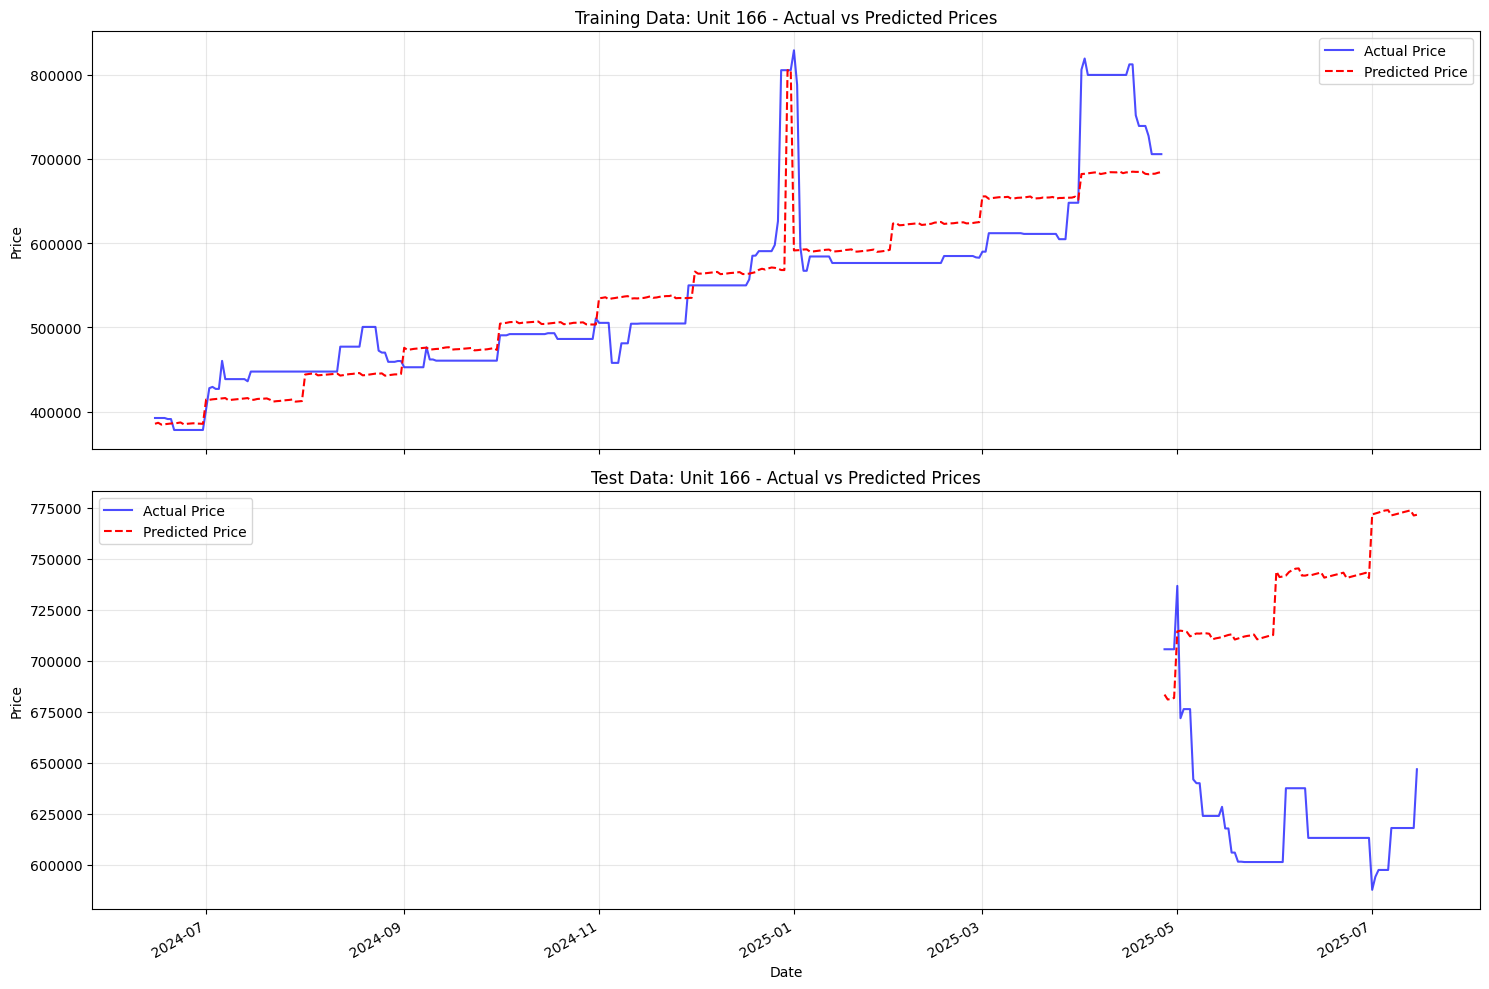

Plotting predictions on the full unit DataFrame...
Columns used for prediction: ['dayofweek', 'month', 'year', 'dayofyear', 'weekofyear', 'taux_occupation_166']


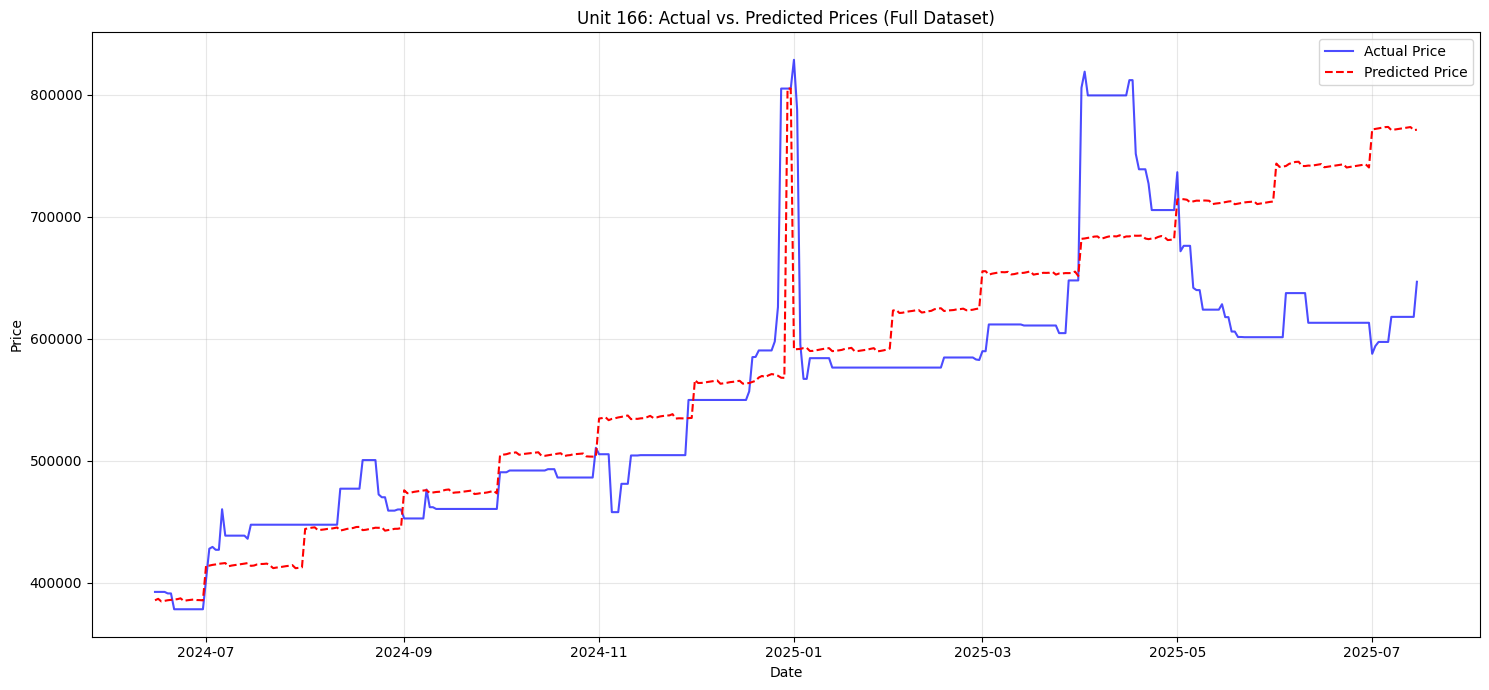


Pipeline finished for Unit 166.
--- End Linear Regression Pipeline ---


In [14]:
linear_results_166 = run_linear_regression_pipeline(df_166, '166', test_size=0.2)

--- Starting Linear Regression Pipeline for Unit 167 ---

[Step 1/3] Splitting data with test_size=0.2...
split complete. Test size: 0.20
Training set range: 2024-06-15 00:00:00 to 2025-04-26 00:00:00 (316 samples)
Testing set range: 2025-04-27 00:00:00 to 2025-07-15 00:00:00 (80 samples)

[Step 2/3] Training and evaluating Linear Regression model...

Training Linear Regression model for target: total_price_167
Features used (X): ['dayofweek', 'month', 'year', 'dayofyear', 'weekofyear', 'taux_occupation_167']
Training set size: 316 samples
Testing set size: 80 samples

Model Evaluation Metrics:
Train RMSE: 8470.94
Test RMSE: 16112.33
Train MAE: 6305.87
Test MAE: 14457.81
Train R²: 0.4608
Test R²: -10.7790

Feature Importance (Coefficients):
               Feature   Coefficient
2                 year  17731.841962
1                month  11031.514952
5  taux_occupation_167   3392.986892
3            dayofyear   -289.933154
0            dayofweek   -168.186176
4           weekofyear    -

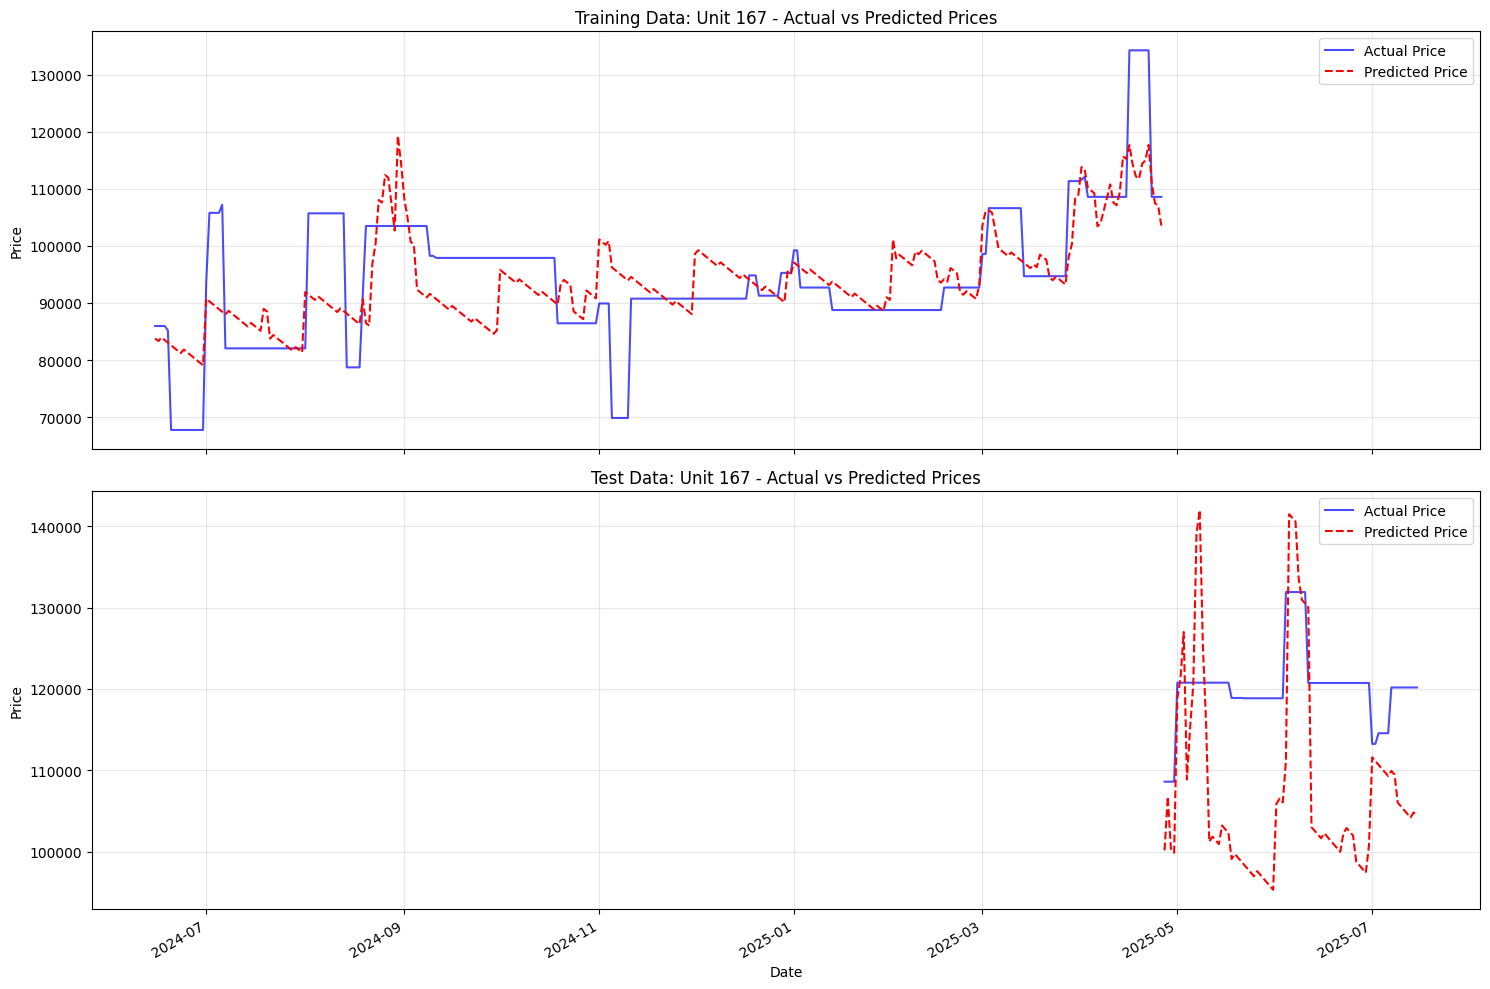

Plotting predictions on the full unit DataFrame...
Columns used for prediction: ['dayofweek', 'month', 'year', 'dayofyear', 'weekofyear', 'taux_occupation_167']


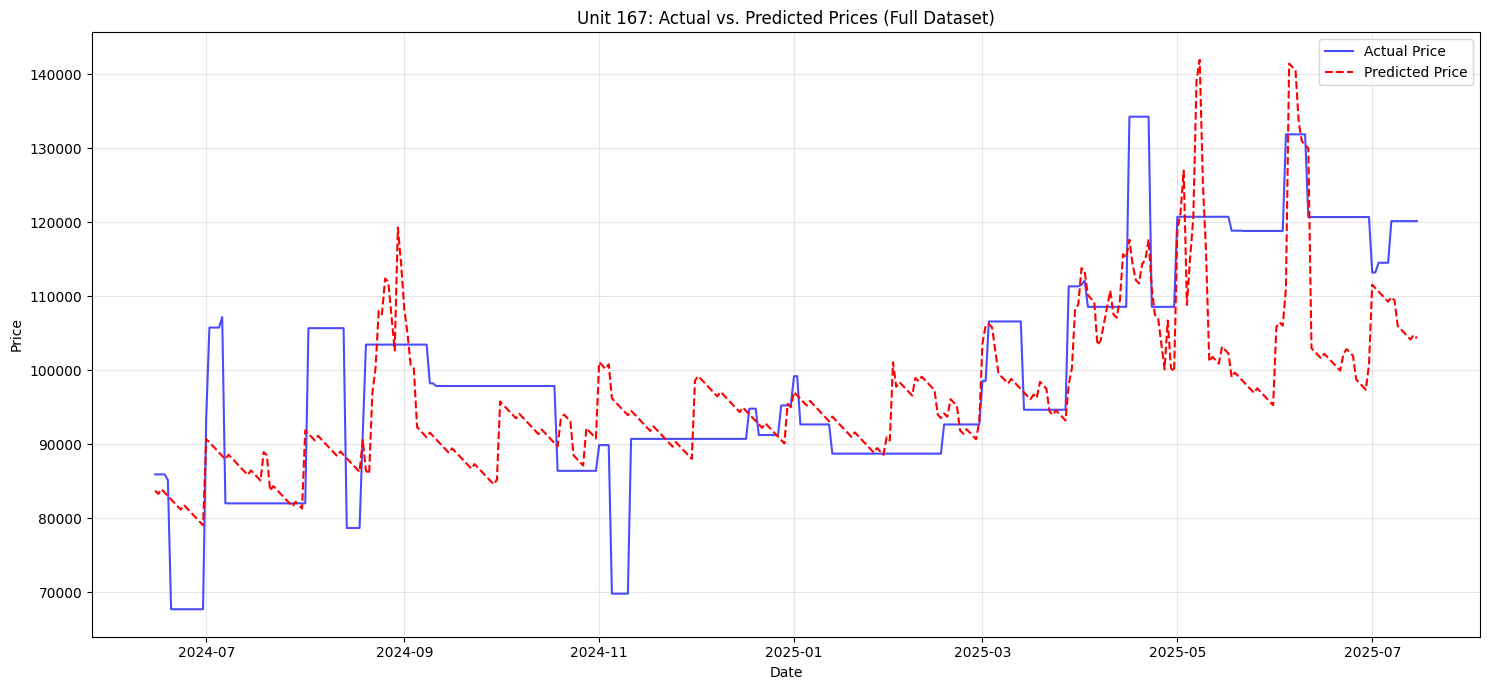


Pipeline finished for Unit 167.
--- End Linear Regression Pipeline ---


In [15]:
linear_results_167 = run_linear_regression_pipeline(df_167, '167', test_size=0.2)

In [16]:
def save_model(model_results, folder_path, model_name):
    """
    Save only the trained model using pickle to a specified folder path.
    """
    if not os.path.exists(folder_path):
        os.makedirs(folder_path)
        print(f"Created directory: {folder_path}")
    
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    file_path = os.path.join(folder_path, f"{model_name}.pkl")
    
    model = model_results['model']
    
    try:
        with open(file_path, 'wb') as f:
            pickle.dump(model, f)
        print(f"Model successfully saved to {file_path}")
        return file_path
    except Exception as e:
        print(f"Error saving model: {e}")
        return None

In [26]:
save_model(linear_results_166, '../TrainedModels/LinearRegression', 'linear_model_166')

Model successfully saved to ../TrainedModels/LinearRegression\linear_model_166.pkl


'../TrainedModels/LinearRegression\\linear_model_166.pkl'

In [27]:
save_model(linear_results_167, '../TrainedModels/LinearRegression', 'linear_model_167')

Model successfully saved to ../TrainedModels/LinearRegression\linear_model_167.pkl


'../TrainedModels/LinearRegression\\linear_model_167.pkl'

In [17]:
def load_model(folder_path, model_name):
    """
    Load a pickled model from a specified folder path.
    """
    file_path = os.path.join(folder_path, f"{model_name}.pkl")
    
    if not os.path.exists(file_path):
        print(f"Error: Model file not found at {file_path}")
        return None
    
    try:
        with open(file_path, 'rb') as f:
            model = pickle.load(f)
        print(f"Model successfully loaded from {file_path}")
        return model
    except Exception as e:
        print(f"Error loading model: {e}")
        return None

In [18]:
loaded_model_rl_166 = load_model('../TrainedModels/LinearRegression', 'linear_model_166')
loaded_model_rl_167 = load_model('../TrainedModels/LinearRegression', 'linear_model_167')

Model successfully loaded from ../TrainedModels/LinearRegression\linear_model_166.pkl
Model successfully loaded from ../TrainedModels/LinearRegression\linear_model_167.pkl


Columns used for prediction: ['dayofweek', 'month', 'year', 'dayofyear', 'weekofyear', 'taux_occupation_166']


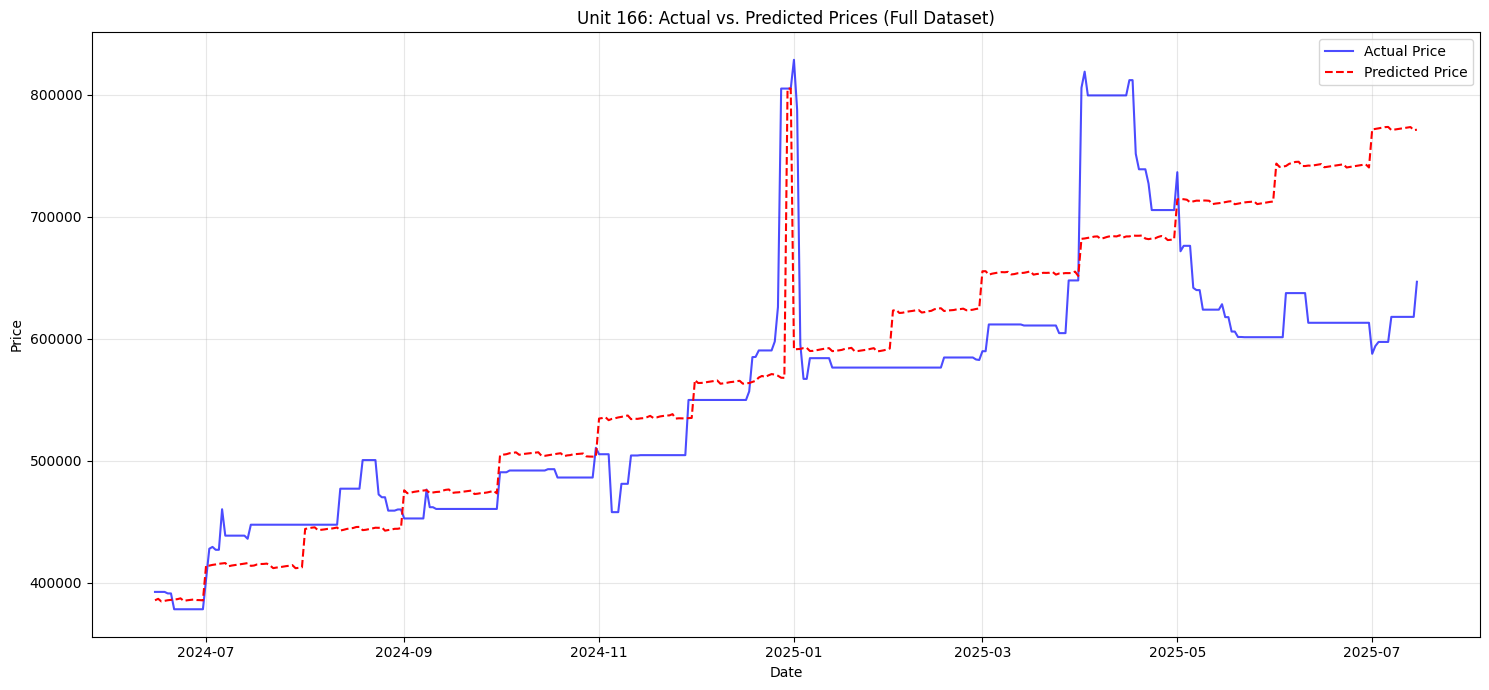

Columns used for prediction: ['dayofweek', 'month', 'year', 'dayofyear', 'weekofyear', 'taux_occupation_167']


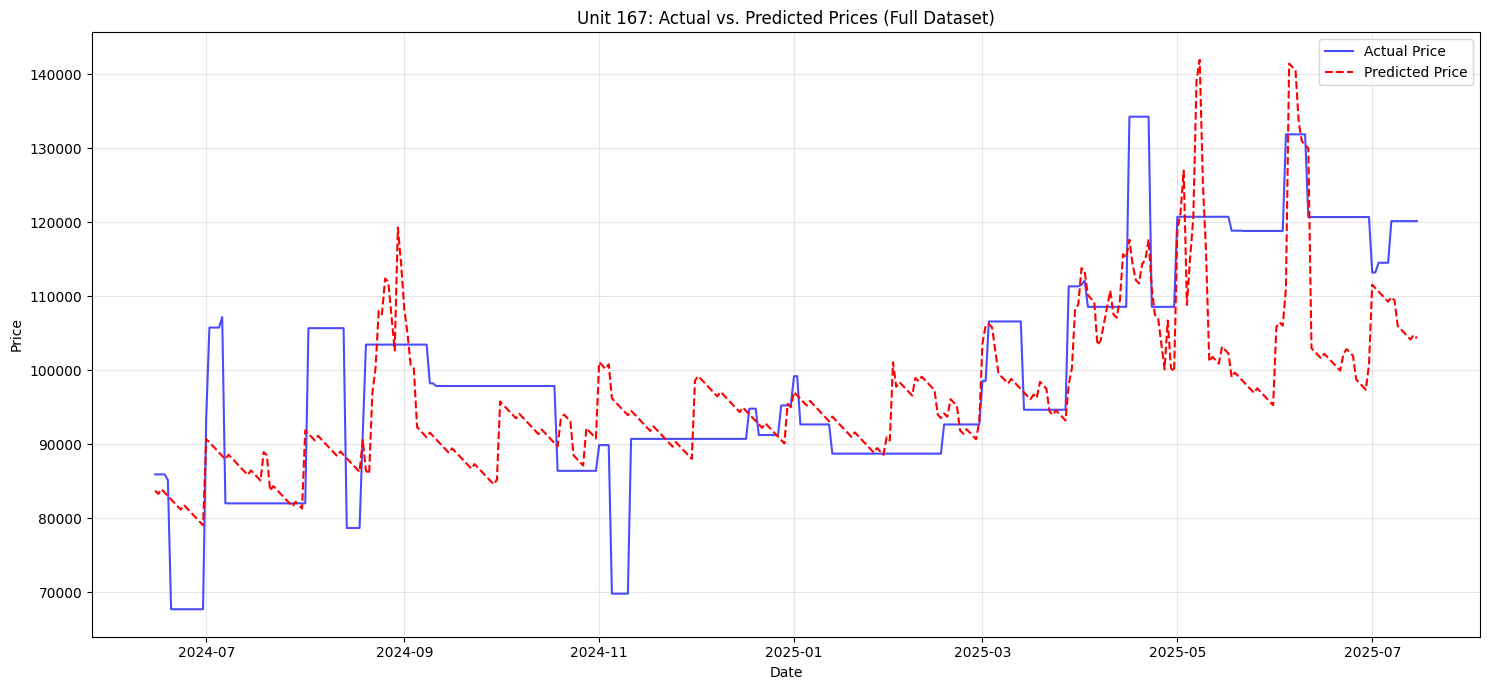

In [21]:
plot_actual_vs_predicted(loaded_model_rl_166, df_166, '166')
plot_actual_vs_predicted(loaded_model_rl_167, df_167, '167')

In [24]:
df1['taux_occupation_166'].max(), df1['taux_occupation_166'].min(), 

(84.49, 0.0)

In [25]:
def predict_single_date_linear_model(model, target_date_str, unit_id, taux_occupation_target):
    """
    Predicts the total_price for a single future date using a trained linear regression model.

    Args:
        model: The trained scikit-learn compatible linear regression model.
        target_date_str (str): The target date for prediction in 'YYYY-MM-DD' format.
        unit_id (str): The identifier for the unit (e.g., '166', '167').
        taux_occupation_target (float): The expected taux_occupation for the target date.
    """
    try:
        target_date = pd.to_datetime(target_date_str)
    except ValueError:
        print(f"Error: Invalid target_date_str format: {target_date_str}. Please use 'YYYY-MM-DD'.")
        return None

    features = {
        'dayofweek': target_date.dayofweek,
        'month': target_date.month,
        'year': target_date.year,
        'dayofyear': target_date.dayofyear,
        'weekofyear': int(target_date.isocalendar().week), 
        f'taux_occupation_{unit_id}': taux_occupation_target
    }

    feature_order = ['dayofweek', 'month', 'year', 'dayofyear', 'weekofyear', f'taux_occupation_{unit_id}']
    
    try:
        input_df = pd.DataFrame([features], columns=feature_order)
    except Exception as e:
        print(f"Error creating DataFrame for prediction: {e}")
        return None
        
    for col in feature_order:
        if col not in input_df.columns:
            print(f"Error: Missing expected feature '{col}' in the generated input.")
            return None
            
    print(f"\nPredicting for Unit {unit_id} on {target_date_str} with features:")
    print(input_df)

    try:
        prediction = model.predict(input_df)
        return prediction[0]  
    except Exception as e:
        print(f"Error during prediction: {e}")

        if hasattr(model, 'feature_names_in_'):
            print(f"Model was trained with features: {model.feature_names_in_}")
        print(f"Input features provided: {input_df.columns.tolist()}")
        
        return None

In [28]:
predict_single_date_linear_model(loaded_model_rl_166, '2025-04-04', '166', 15.68)


Predicting for Unit 166 on 2025-04-04 with features:
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_166
0          4      4  2025         94          14                15.68


683193.7053090334

In [29]:
df_166[df_166['taux_occupation_166'] == 15.68]

,dayofweek,month,year,dayofyear,weekofyear,total_price_166,taux_occupation_166
date,,,,,,,
2025-04-04,4,4,2025,94,14,799603.915,15.68


In [31]:
predict_single_date_linear_model(loaded_model_rl_167, '2025-04-04', '167', 2.36)


Predicting for Unit 167 on 2025-04-04 with features:
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_167
0          4      4  2025         94          14                 2.36


109703.47855141759

In [32]:
df_167[df_167['taux_occupation_167'] == 2.36]

,dayofweek,month,year,dayofyear,weekofyear,total_price_167,taux_occupation_167
date,,,,,,,
2025-03-29,5,3,2025,88,13,111363.412,2.36
2025-04-03,3,4,2025,93,14,108595.456,2.36
2025-04-04,4,4,2025,94,14,108595.456,2.36
2025-04-05,5,4,2025,95,14,108595.456,2.36
2025-04-09,2,4,2025,99,15,108595.456,2.36
2025-04-11,4,4,2025,101,15,108595.456,2.36
2025-04-12,5,4,2025,102,15,108595.456,2.36


In [34]:
def find_max_price_for_date_linear_model(model, target_date_str, unit_id, min_taux=0.0, max_taux=95.0, step=0.01):
    """
    Finds the taux_occupation that maximizes the predicted price for a single date
    by iterating through a range of taux_occupation values.

    Args:
        model: The trained scikit-learn compatible linear regression model.
        target_date_str (str): The target date for prediction in 'YYYY-MM-DD' format.
        unit_id (str): The identifier for the unit (e.g., '166', '167').
        min_taux (float): Minimum taux_occupation to test.
        max_taux (float): Maximum taux_occupation to test.
        step (float): Step for iterating taux_occupation.
    """
    best_taux_occupation = None
    max_predicted_price = -float('inf')  

    print(f"\nSearching for optimal taux_occupation for unit {unit_id} on {target_date_str} (range: {min_taux}-{max_taux}, step: {step})...")
    
    num_steps = int((max_taux - min_taux) / step) + 1
    taux_values = np.linspace(min_taux, max_taux, num_steps)

    for taux in tqdm(taux_values, desc="Testing taux_occupation values"):
        predicted_price = predict_single_date_linear_model(model, target_date_str, unit_id, taux)
        
        if predicted_price is not None:
            if predicted_price > max_predicted_price:
                max_predicted_price = predicted_price
                best_taux_occupation = taux
    
    if best_taux_occupation is not None:
        print(f"Search complete. Optimal taux_occupation: {best_taux_occupation:.2f} -> Max Price: {max_predicted_price:.2f}")
        return best_taux_occupation, max_predicted_price
    else:
        print("Search complete. No valid predictions found.")
        return None, None


In [41]:
find_max_price_for_date_linear_model(loaded_model_rl_166, '2025-01-03', '166', min_taux=0.0, max_taux=80.0, step=0.1)


Searching for optimal taux_occupation for unit 166 on 2025-01-03 (range: 0.0-80.0, step: 0.1)...


Testing taux_occupation values:   4%|▍         | 31/801 [00:00<00:02, 304.64it/s]


Predicting for Unit 166 on 2025-01-03 with features:
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_166
0          4      1  2025          3           1                  0.0

Predicting for Unit 166 on 2025-01-03 with features:
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_166
0          4      1  2025          3           1                  0.1

Predicting for Unit 166 on 2025-01-03 with features:
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_166
0          4      1  2025          3           1                  0.2

Predicting for Unit 166 on 2025-01-03 with features:
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_166
0          4      1  2025          3           1                  0.3

Predicting for Unit 166 on 2025-01-03 with features:
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_166
0          4      1  2025          3           1                  0.4

Predicting for Unit 166 on 20

Testing taux_occupation values:  13%|█▎        | 108/801 [00:00<00:01, 363.80it/s]


Predicting for Unit 166 on 2025-01-03 with features:
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_166
0          4      1  2025          3           1                  6.9

Predicting for Unit 166 on 2025-01-03 with features:
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_166
0          4      1  2025          3           1                  7.0

Predicting for Unit 166 on 2025-01-03 with features:
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_166
0          4      1  2025          3           1                  7.1

Predicting for Unit 166 on 2025-01-03 with features:
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_166
0          4      1  2025          3           1                  7.2

Predicting for Unit 166 on 2025-01-03 with features:
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_166
0          4      1  2025          3           1                  7.3

Predicting for Unit 166 on 20

...

Testing taux_occupation values:  94%|█████████▍| 754/801 [00:02<00:00, 355.37it/s]


Predicting for Unit 166 on 2025-01-03 with features:
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_166
0          4      1  2025          3           1                 67.8

Predicting for Unit 166 on 2025-01-03 with features:
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_166
0          4      1  2025          3           1                 67.9

Predicting for Unit 166 on 2025-01-03 with features:
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_166
0          4      1  2025          3           1                 68.0

Predicting for Unit 166 on 2025-01-03 with features:
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_166
0          4      1  2025          3           1                 68.1

Predicting for Unit 166 on 2025-01-03 with features:
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_166
0          4      1  2025          3           1                 68.2

Predicting for Unit 166 on 20

Testing taux_occupation values: 100%|██████████| 801/801 [00:02<00:00, 360.86it/s]


Predicting for Unit 166 on 2025-01-03 with features:
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_166
0          4      1  2025          3           1                 79.3

Predicting for Unit 166 on 2025-01-03 with features:
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_166
0          4      1  2025          3           1                 79.4

Predicting for Unit 166 on 2025-01-03 with features:
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_166
0          4      1  2025          3           1                 79.5

Predicting for Unit 166 on 2025-01-03 with features:
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_166
0          4      1  2025          3           1                 79.6

Predicting for Unit 166 on 2025-01-03 with features:
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_166
0          4      1  2025          3           1                 79.7

Predicting for Unit 166 on 20

(80.0, 598487.9531226158)

## Train the `LSTM model`

In [42]:
X_train_166, X_test_166, y_train_166, y_test_166, target_col_166 = split_data_train_test(df_166, 166)
X_train_167, X_test_167, y_train_167, y_test_167, target_col_167 = split_data_train_test(df_167, 167)

split complete. Test size: 0.20
Training set range: 2024-06-15 00:00:00 to 2025-04-26 00:00:00 (316 samples)
Testing set range: 2025-04-27 00:00:00 to 2025-07-15 00:00:00 (80 samples)
split complete. Test size: 0.20
Training set range: 2024-06-15 00:00:00 to 2025-04-26 00:00:00 (316 samples)
Testing set range: 2025-04-27 00:00:00 to 2025-07-15 00:00:00 (80 samples)


In [43]:
def create_sequences(input_data, target_data, sequence_length):
    """
    Creates sequences for LSTM model training.
    """
    sequences = []
    targets = []
    data_len = len(input_data)
    for i in range(data_len - sequence_length):
        seq_end = i + sequence_length
        sequences.append(input_data[i:seq_end])
        targets.append(target_data[seq_end]) 
    return np.array(sequences), np.array(targets)


class LSTMModel(nn.Module):
    def __init__(self, input_dim, hidden_dim=80, num_layers=2, dropout=0.2):
        super(LSTMModel, self).__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers

        self.lstm = nn.LSTM(
            input_dim,
            hidden_dim,
            num_layers=num_layers,
            batch_first=True, 
            dropout=dropout if num_layers > 1 else 0
        )

        self.batch_norm = nn.BatchNorm1d(hidden_dim)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, 1) 

    def forward(self, x):
        # x shape: (batch_size, seq_len, input_dim)
        lstm_out, _ = self.lstm(x) 

        # We only need the output of the last time step
        last_time_step_out = lstm_out[:, -1, :] 

        out = self.batch_norm(last_time_step_out)
        out = self.dropout(out)
        out = self.fc(out) # Shape: (batch_size, 1)
        return out


def train_evaluate_lstm_model(X_train, X_test, y_train, y_test, target_col,
                              sequence_length=10, batch_size=32, epochs=50,
                              learning_rate=0.001, hidden_dim=80, num_layers=2, dropout=0.2,
                              device='cuda' if torch.cuda.is_available() else 'cpu'):
    """
    Trains and evaluates an LSTM model using pre-split data.
    """
    print(f"\nTraining LSTM model for target: {target_col}")
    print(f"Hyperparameters: seq_len={sequence_length}, batch={batch_size}, epochs={epochs}, lr={learning_rate}")
    print(f"Features used (X): {X_train.columns.tolist()}")

    feature_scaler = MinMaxScaler()
    X_train_scaled = feature_scaler.fit_transform(X_train)
    X_test_scaled = feature_scaler.transform(X_test)

    target_scaler = MinMaxScaler()
    y_train_scaled = target_scaler.fit_transform(y_train.values.reshape(-1, 1))
    y_test_scaled = target_scaler.transform(y_test.values.reshape(-1, 1))

    X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train_scaled, sequence_length)
    X_test_seq, y_test_seq = create_sequences(X_test_scaled, y_test_scaled, sequence_length)

    if len(X_train_seq) == 0 or len(X_test_seq) == 0:
        raise ValueError(f"Not enough data to create sequences with length {sequence_length}. "
                         f"Train length: {len(X_train)}, Test length: {len(X_test)}")

    X_train_tensor = torch.tensor(X_train_seq, dtype=torch.float32).to(device)
    y_train_tensor = torch.tensor(y_train_seq, dtype=torch.float32).to(device)
    X_test_tensor = torch.tensor(X_test_seq, dtype=torch.float32).to(device)
    y_test_tensor = torch.tensor(y_test_seq, dtype=torch.float32).to(device)

    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True) 

    test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False) 

    input_dim = X_train.shape[1] 
    model = LSTMModel(input_dim, hidden_dim, num_layers, dropout).to(device)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    loss_history = []

    print("\nStarting Training...")
    for epoch in range(epochs):
        model.train() 
        epoch_loss = 0
        progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}", leave=False)
        for batch_X, batch_y in progress_bar:
            optimizer.zero_grad()
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
            progress_bar.set_postfix(loss=loss.item())

        avg_epoch_loss = epoch_loss / len(train_loader)
        loss_history.append(avg_epoch_loss)

        if (epoch + 1) % 10 == 0 or epoch == epochs - 1: 
             print(f"Epoch [{epoch+1}/{epochs}], Loss: {avg_epoch_loss:.6f}")

    print("Training Finished.")

    model.eval() 
    train_predictions_scaled = []
    train_actuals_scaled = []
    test_predictions_scaled = []
    test_actuals_scaled = []

    with torch.no_grad():

        for batch_X, batch_y in DataLoader(train_dataset, batch_size=batch_size, shuffle=False):
             outputs = model(batch_X)
             train_predictions_scaled.extend(outputs.cpu().numpy())
             train_actuals_scaled.extend(batch_y.cpu().numpy())

        for batch_X, batch_y in test_loader:
            outputs = model(batch_X)
            test_predictions_scaled.extend(outputs.cpu().numpy())
            test_actuals_scaled.extend(batch_y.cpu().numpy())

    train_predictions_scaled = np.array(train_predictions_scaled)
    train_actuals_scaled = np.array(train_actuals_scaled)
    test_predictions_scaled = np.array(test_predictions_scaled)
    test_actuals_scaled = np.array(test_actuals_scaled)

    y_train_pred = target_scaler.inverse_transform(train_predictions_scaled)
    y_train_actual = target_scaler.inverse_transform(train_actuals_scaled)
    y_test_pred = target_scaler.inverse_transform(test_predictions_scaled)
    y_test_actual = target_scaler.inverse_transform(test_actuals_scaled)

    train_rmse = np.sqrt(mean_squared_error(y_train_actual, y_train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test_actual, y_test_pred))
    train_mae = mean_absolute_error(y_train_actual, y_train_pred)
    test_mae = mean_absolute_error(y_test_actual, y_test_pred)
    train_r2 = r2_score(y_train_actual, y_train_pred)
    test_r2 = r2_score(y_test_actual, y_test_pred)

    print("\nModel Evaluation Metrics:")
    print(f"Train RMSE: {train_rmse:.2f}")
    print(f"Test RMSE: {test_rmse:.2f}")
    print(f"Train MAE: {train_mae:.2f}")
    print(f"Test MAE: {test_mae:.2f}")
    print(f"Train R²: {train_r2:.4f}")
    print(f"Test R²: {test_r2:.4f}")

    y_train_matched = y_train[sequence_length:]
    y_test_matched = y_test[sequence_length:]


    return {
        'model': model,
        'feature_scaler': feature_scaler,
        'target_scaler': target_scaler,
        'sequence_length': sequence_length,
        'X_train_orig': X_train,
        'X_test_orig': X_test,
        'y_train_orig': y_train,
        'y_test_orig': y_test,
        'y_train_actual': y_train_actual.flatten(), 
        'y_test_actual': y_test_actual.flatten(),
        'y_train_pred': y_train_pred.flatten(),
        'y_test_pred': y_test_pred.flatten(),
        'metrics': {
            'train_rmse': train_rmse,
            'test_rmse': test_rmse,
            'train_mae': train_mae,
            'test_mae': test_mae,
            'train_r2': train_r2,
            'test_r2': test_r2
        },
        'y_train_indices': y_train_matched.index,
        'y_test_indices': y_test_matched.index,
        'loss_history': loss_history
    }

def plot_lstm_loss(lstm_results, unit_id):
    """
    Plots the training loss per epoch for the LSTM model.
    """
    if 'loss_history' not in lstm_results:
        print("Error: 'loss_history' not found in lstm_results. "
              "Ensure the training function stores and returns it.")
        return

    loss_history = lstm_results['loss_history']
    epochs = range(1, len(loss_history) + 1)

    plt.figure(figsize=(10, 6))
    plt.plot(epochs, loss_history, 'bo-', label='Training Loss (MSE)')
    plt.title(f'Unit {unit_id}: LSTM Training Loss per Epoch')
    plt.xlabel('Epoch')
    plt.ylabel('Average MSE Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_lstm_predictions_over_time(lstm_results, unit_id):
    """
    Plots actual vs. predicted values over time for LSTM model results.
    """

    required_keys = ['y_train_actual', 'y_train_pred', 'y_train_indices',
                     'y_test_actual', 'y_test_pred', 'y_test_indices']
    
    if not all(key in lstm_results for key in required_keys):
        print("Error: lstm_results dictionary is missing required keys for plotting.")
        print(f"Required keys: {required_keys}")
        return

    y_train_actual = lstm_results['y_train_actual']
    y_train_pred = lstm_results['y_train_pred']
    train_indices = lstm_results['y_train_indices']

    y_test_actual = lstm_results['y_test_actual']
    y_test_pred = lstm_results['y_test_pred']
    test_indices = lstm_results['y_test_indices']

    if len(y_train_actual) != len(train_indices) or len(y_train_pred) != len(train_indices):
        print("Warning: Length mismatch between training predictions/actuals and indices.")

        min_len_train = min(len(y_train_actual), len(y_train_pred), len(train_indices))
        y_train_actual = y_train_actual[:min_len_train]
        y_train_pred = y_train_pred[:min_len_train]
        train_indices = train_indices[:min_len_train]


    if len(y_test_actual) != len(test_indices) or len(y_test_pred) != len(test_indices):
        print("Warning: Length mismatch between testing predictions/actuals and indices.")
        min_len_test = min(len(y_test_actual), len(y_test_pred), len(test_indices))
        y_test_actual = y_test_actual[:min_len_test]
        y_test_pred = y_test_pred[:min_len_test]
        test_indices = test_indices[:min_len_test]


    train_plot_df = pd.DataFrame({
        'Actual': y_train_actual,
        'Predicted': y_train_pred
    }, index=train_indices)

    test_plot_df = pd.DataFrame({
        'Actual': y_test_actual,
        'Predicted': y_test_pred
    }, index=test_indices)

    fig, axes = plt.subplots(2, 1, figsize=(15, 10), sharex=True)

    axes[0].plot(train_plot_df.index, train_plot_df['Actual'], 'b-', label='Actual Price', alpha=0.7)
    axes[0].plot(train_plot_df.index, train_plot_df['Predicted'], 'r--', label='Predicted Price')
    axes[0].set_title(f'Training Data: Unit {unit_id} - LSTM Actual vs Predicted Prices')
    axes[0].set_ylabel('Price')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(test_plot_df.index, test_plot_df['Actual'], 'b-', label='Actual Price', alpha=0.7)
    axes[1].plot(test_plot_df.index, test_plot_df['Predicted'], 'r--', label='Predicted Price')
    axes[1].set_title(f'Test Data: Unit {unit_id} - LSTM Actual vs Predicted Prices')
    axes[1].set_xlabel('Date')
    axes[1].set_ylabel('Price')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    fig.autofmt_xdate()

    plt.tight_layout()
    plt.show()


def plot_lstm_predictions_on_dataframe(df, unit_id, model, feature_scaler, target_scaler, sequence_length, device):
    """
    Uses a trained LSTM model to predict on a given DataFrame and plots actual vs. predicted values.
    """
    df_copy = df.copy()
    target_col = f'total_price_{unit_id}'

    if target_col not in df_copy.columns:
        print(f"Error: Target column '{target_col}' not found in DataFrame.")
        return

    if isinstance(df_copy.index, pd.DatetimeIndex):
        df_copy = df_copy.sort_index()


    if hasattr(feature_scaler, 'feature_names_in_'):
        feature_cols = feature_scaler.feature_names_in_
    else:
        feature_cols = df_copy.drop(target_col, axis=1).columns
        print(f"Warning: Inferring feature columns: {feature_cols.tolist()}")

    try:
        X = df_copy[feature_cols]
        y = df_copy[target_col]
    except KeyError as e:
        print(f"Error: Missing feature column in DataFrame: {e}")
        return

    X_scaled = feature_scaler.transform(X)
    y_scaled = target_scaler.transform(y.values.reshape(-1, 1))

    try:
        X_seq, y_seq = create_sequences(X_scaled, y_scaled, sequence_length)
    except ValueError as e:
        print(f"Error creating sequences: {e}")
        return
    if len(X_seq) == 0:
        print(f"Error: Not enough data in the DataFrame (length {len(df_copy)}) to create sequences of length {sequence_length}.")
        return

    X_tensor = torch.tensor(X_seq, dtype=torch.float32).to(device)

    model.eval() 
    predictions_scaled = []
    with torch.no_grad():
        outputs = model(X_tensor)
        predictions_scaled = outputs.cpu().numpy()

    y_pred = target_scaler.inverse_transform(predictions_scaled).flatten()

    y_actual = y.iloc[sequence_length:].values
    actual_indices = df_copy.index[sequence_length:]

    if len(y_pred) != len(y_actual):
         print(f"Warning: Prediction length ({len(y_pred)}) differs from actual length ({len(y_actual)}). Truncating.")
         min_len = min(len(y_pred), len(y_actual))
         y_pred = y_pred[:min_len]
         y_actual = y_actual[:min_len]
         actual_indices = actual_indices[:min_len]


    plot_df = pd.DataFrame({
        'Actual': y_actual,
        'Predicted': y_pred
    }, index=actual_indices)

    plt.figure(figsize=(15, 7))
    plt.plot(plot_df.index, plot_df['Actual'], 'b-', label='Actual Price', alpha=0.7)
    plt.plot(plot_df.index, plot_df['Predicted'], 'r--', label='Predicted Price')
    plt.title(f'Unit {unit_id}: LSTM Actual vs. Predicted Prices')
    plt.xlabel('Date')
    plt.ylabel('Price')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [44]:
def run_lstm_pipeline(df_unit, unit_id, test_size=0.2,
                      sequence_length=7, batch_size=16, epochs=100,
                      learning_rate=0.001, hidden_dim=64, num_layers=2, dropout=0.1,
                      device='cuda' if torch.cuda.is_available() else 'cpu'):
    """
    Runs the complete LSTM training, evaluation, and plotting pipeline for a specific unit.

    Args:
        df_unit (pd.DataFrame): The DataFrame containing data for the specific unit.
        unit_id (str): The identifier for the unit (e.g., '166', '167').
        test_size (float): The proportion of the data to use for the test set.
        sequence_length (int): LSTM sequence length.
        batch_size (int): Training batch size.
        epochs (int): Number of training epochs.
        learning_rate (float): Optimizer learning rate.
        hidden_dim (int): LSTM hidden dimension size.
        num_layers (int): Number of LSTM layers.
        dropout (float): Dropout rate.
        device (str): Device to run training on ('cpu' or 'cuda').
    """
    print(f"--- Starting LSTM Pipeline for Unit {unit_id} ---")

    print(f"\n[Step 1/4] Splitting data with test_size={test_size}...")
    try:
        X_train, X_test, y_train, y_test, target_col = split_data_train_test(
            df_unit, unit_id, test_size=test_size
        )
    except ValueError as e:
        print(f"Error during data splitting: {e}")
        return None
    except Exception as e:
         print(f"An unexpected error occurred during data splitting: {e}")
         return None


    print("\n[Step 2/4] Training and evaluating LSTM model...")
    try:
        lstm_results = train_evaluate_lstm_model(
            X_train, X_test, y_train, y_test, target_col,
            sequence_length=sequence_length,
            batch_size=batch_size,
            epochs=epochs,
            learning_rate=learning_rate,
            hidden_dim=hidden_dim,
            num_layers=num_layers,
            dropout=dropout,
            device=device
        )
    except ValueError as e:
        print(f"Error during model training/evaluation: {e}")
        return None
    except Exception as e:
         print(f"An unexpected error occurred during training/evaluation: {e}")
         return None

    print("\n[Step 3/4] Plotting results...")
    try:
        print("Plotting training loss...")
        plot_lstm_loss(lstm_results, unit_id)

        print("Plotting predictions on train/test split...")
        plot_lstm_predictions_over_time(lstm_results, unit_id)

        print("Plotting predictions on the full unit DataFrame...")
        plot_lstm_predictions_on_dataframe(
            df_unit,
            unit_id,
            lstm_results['model'],
            lstm_results['feature_scaler'],
            lstm_results['target_scaler'],
            lstm_results['sequence_length'], 
            device
        )
    except KeyError as e:
        print(f"Error during plotting: Missing key in lstm_results - {e}")
    except Exception as e:
        print(f"An unexpected error occurred during plotting: {e}")


    print(f"\n[Step 4/4] Pipeline finished for Unit {unit_id}.")
    print("--- End LSTM Pipeline ---")

    return lstm_results

--- Starting LSTM Pipeline for Unit 167 ---

[Step 1/4] Splitting data with test_size=0.2...
split complete. Test size: 0.20
Training set range: 2024-06-15 00:00:00 to 2025-04-26 00:00:00 (316 samples)
Testing set range: 2025-04-27 00:00:00 to 2025-07-15 00:00:00 (80 samples)

[Step 2/4] Training and evaluating LSTM model...

Training LSTM model for target: total_price_167
Hyperparameters: seq_len=10, batch=16, epochs=80, lr=0.001
Features used (X): ['dayofweek', 'month', 'year', 'dayofyear', 'weekofyear', 'taux_occupation_167']

Starting Training...


Epoch 1/80:   0%|          | 0/20 [00:00<?, ?it/s, loss=0.387]

Epoch [10/80], Loss: 0.046198


Epoch [20/80], Loss: 0.032693


Epoch [30/80], Loss: 0.024585


Epoch [40/80], Loss: 0.022820


Epoch [50/80], Loss: 0.019096


Epoch [60/80], Loss: 0.019231


Epoch [70/80], Loss: 0.015961


Epoch [80/80], Loss: 0.015954
Training Finished.

Model Evaluation Metrics:
Train RMSE: 8238.30
Test RMSE: 9341.67
Train MAE: 6479.68
Test MAE: 8098.07
Train R²: 0.4554
Test R²: -4.0866

[Step 3/4] Plotting results...
Plotting training loss...


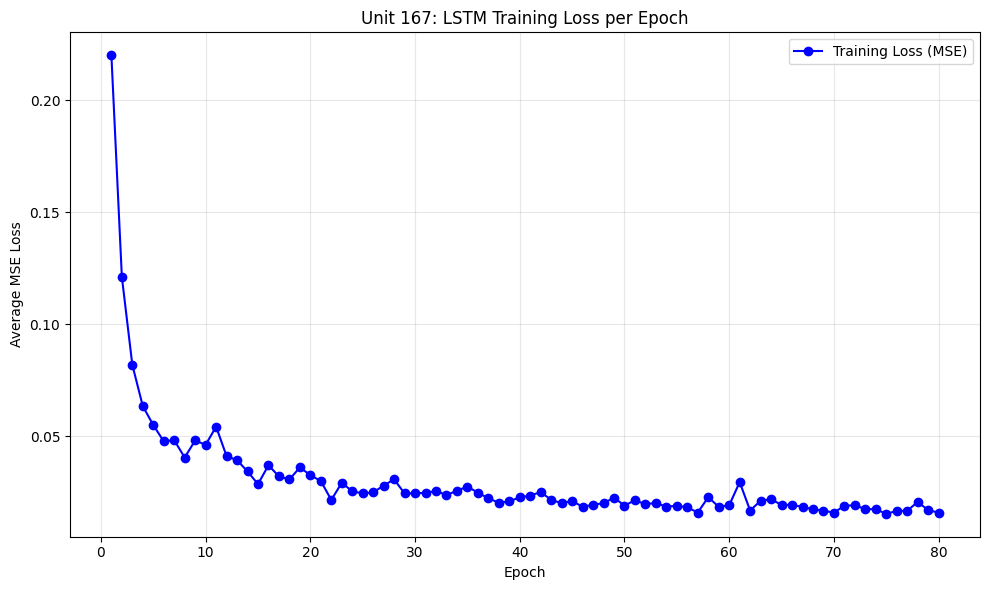

Plotting predictions on train/test split...


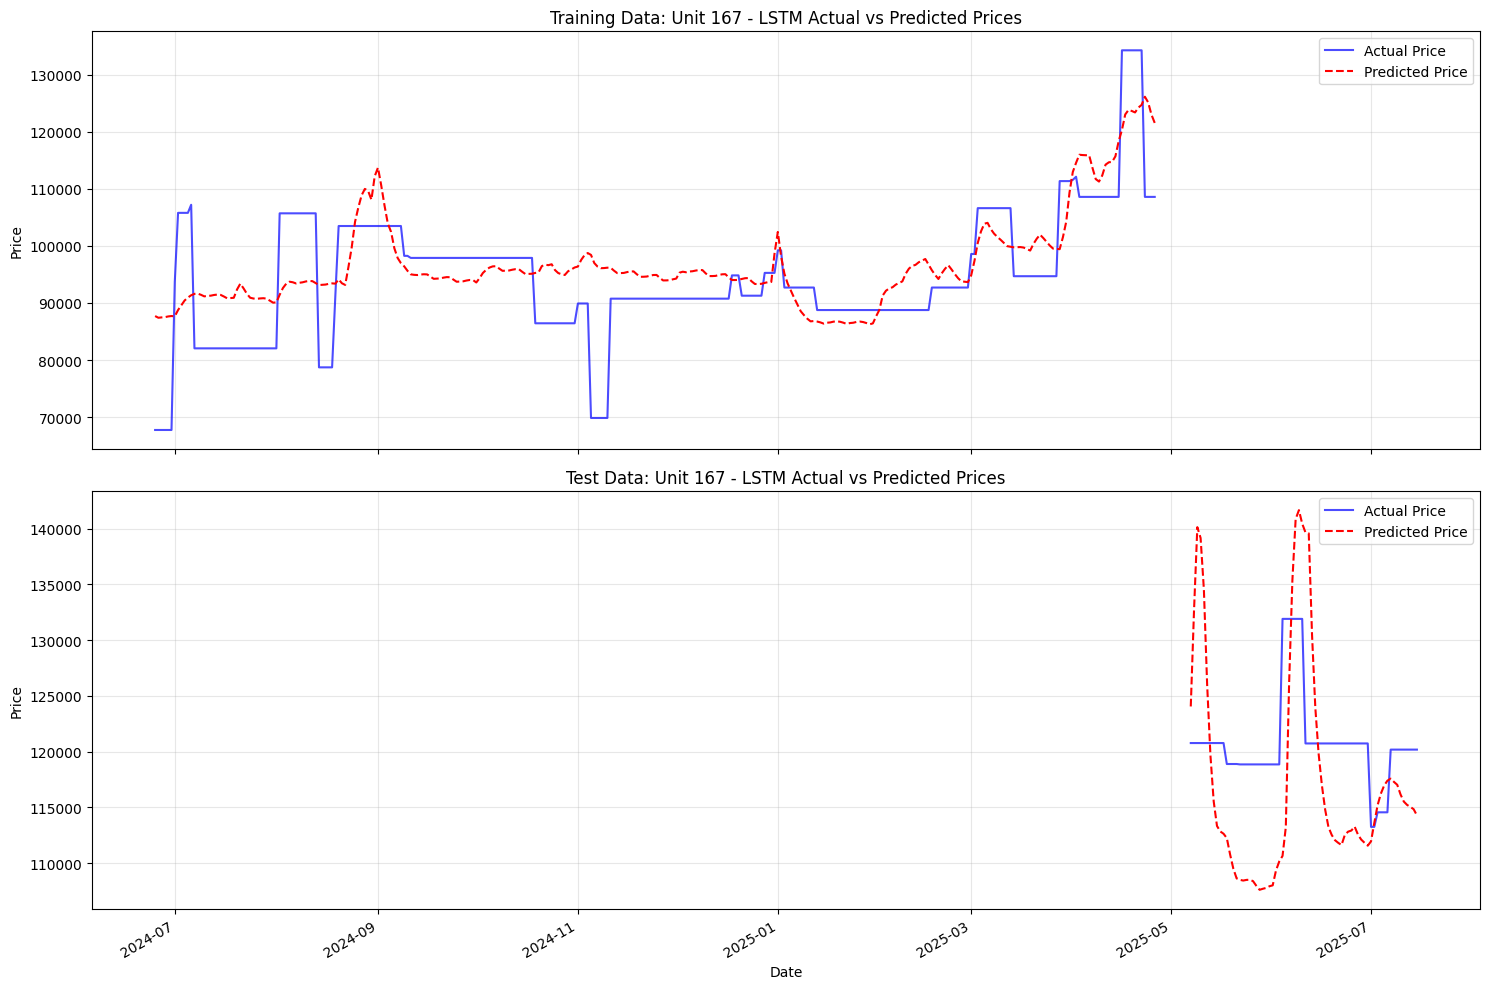

Plotting predictions on the full unit DataFrame...


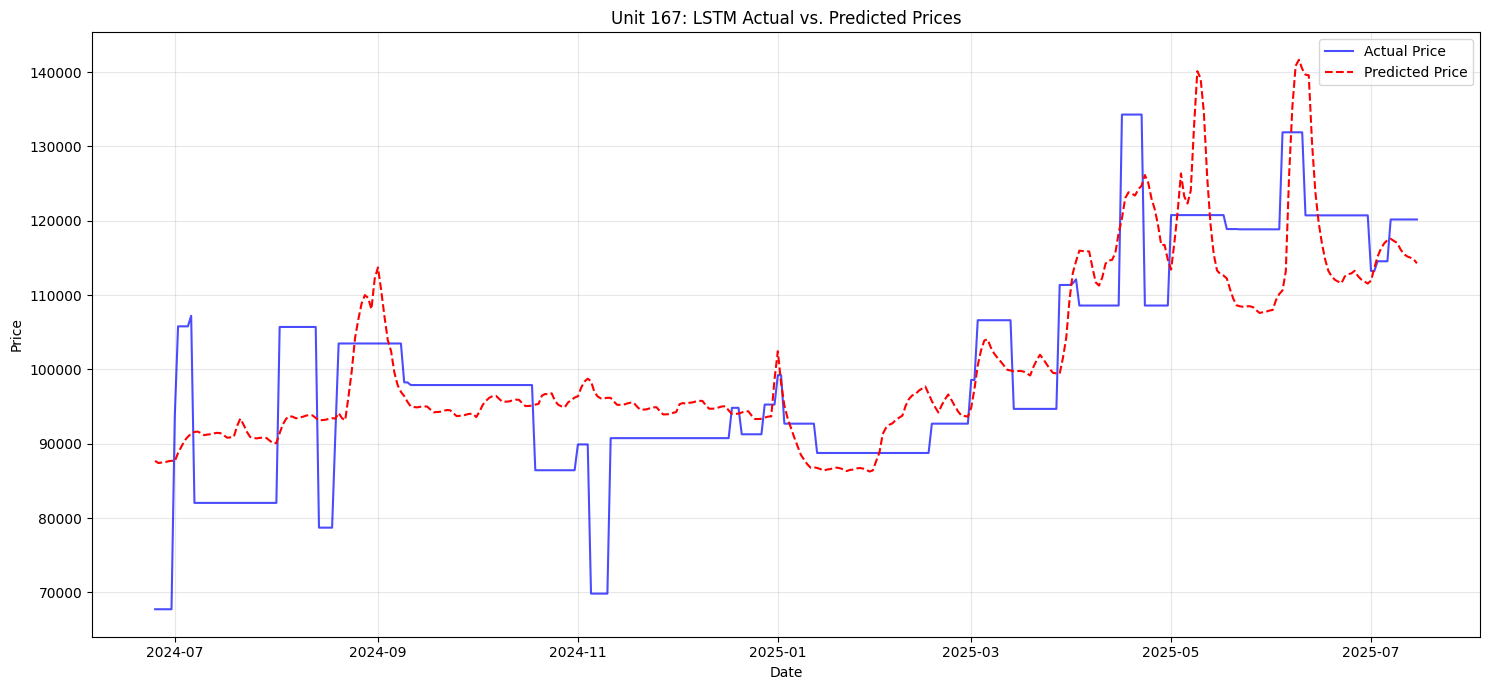


[Step 4/4] Pipeline finished for Unit 167.
--- End LSTM Pipeline ---


In [18]:
results_lstm_167 = run_lstm_pipeline(
    df_167,
    '167',
    test_size=0.2,
    sequence_length=10, 
    epochs=80,
)

--- Starting LSTM Pipeline for Unit 166 ---

[Step 1/4] Splitting data with test_size=0.2...
split complete. Test size: 0.20
Training set range: 2024-06-15 00:00:00 to 2025-04-26 00:00:00 (316 samples)
Testing set range: 2025-04-27 00:00:00 to 2025-07-15 00:00:00 (80 samples)

[Step 2/4] Training and evaluating LSTM model...

Training LSTM model for target: total_price_166
Hyperparameters: seq_len=10, batch=16, epochs=80, lr=0.001
Features used (X): ['dayofweek', 'month', 'year', 'dayofyear', 'weekofyear', 'taux_occupation_166']

Starting Training...


Epoch 1/80:   0%|          | 0/20 [00:00<?, ?it/s]

Epoch [10/80], Loss: 0.046695


Epoch [20/80], Loss: 0.028104


Epoch [30/80], Loss: 0.019556


Epoch [40/80], Loss: 0.018917


Epoch [50/80], Loss: 0.017619


Epoch [60/80], Loss: 0.011695


Epoch [70/80], Loss: 0.011757


Epoch [80/80], Loss: 0.010735
Training Finished.

Model Evaluation Metrics:
Train RMSE: 28398.09
Test RMSE: 568678.09
Train MAE: 19900.62
Test MAE: 549669.69
Train R²: 0.9219
Test R²: -1893.6333

[Step 3/4] Plotting results...
Plotting training loss...


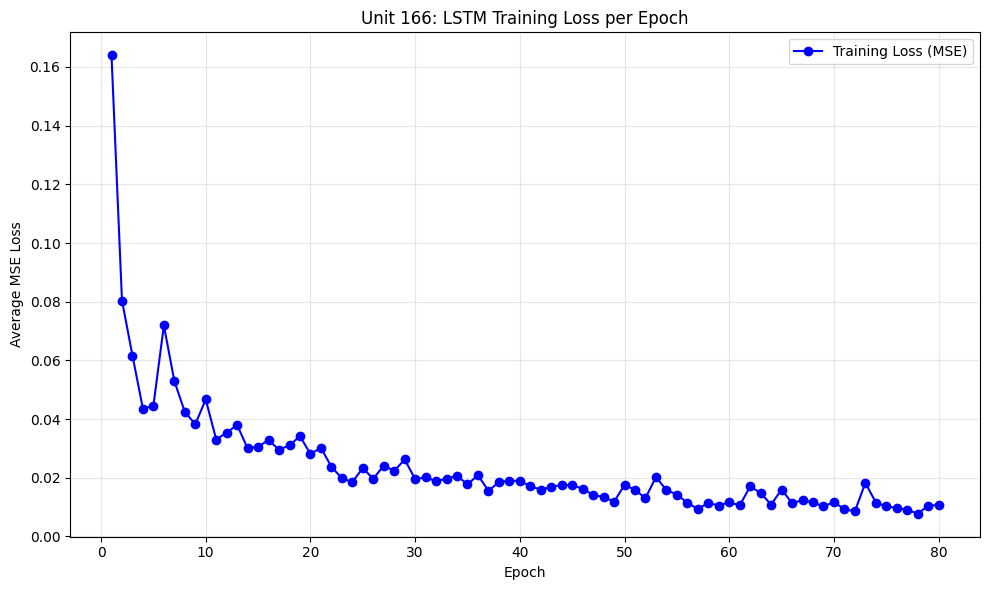

Plotting predictions on train/test split...


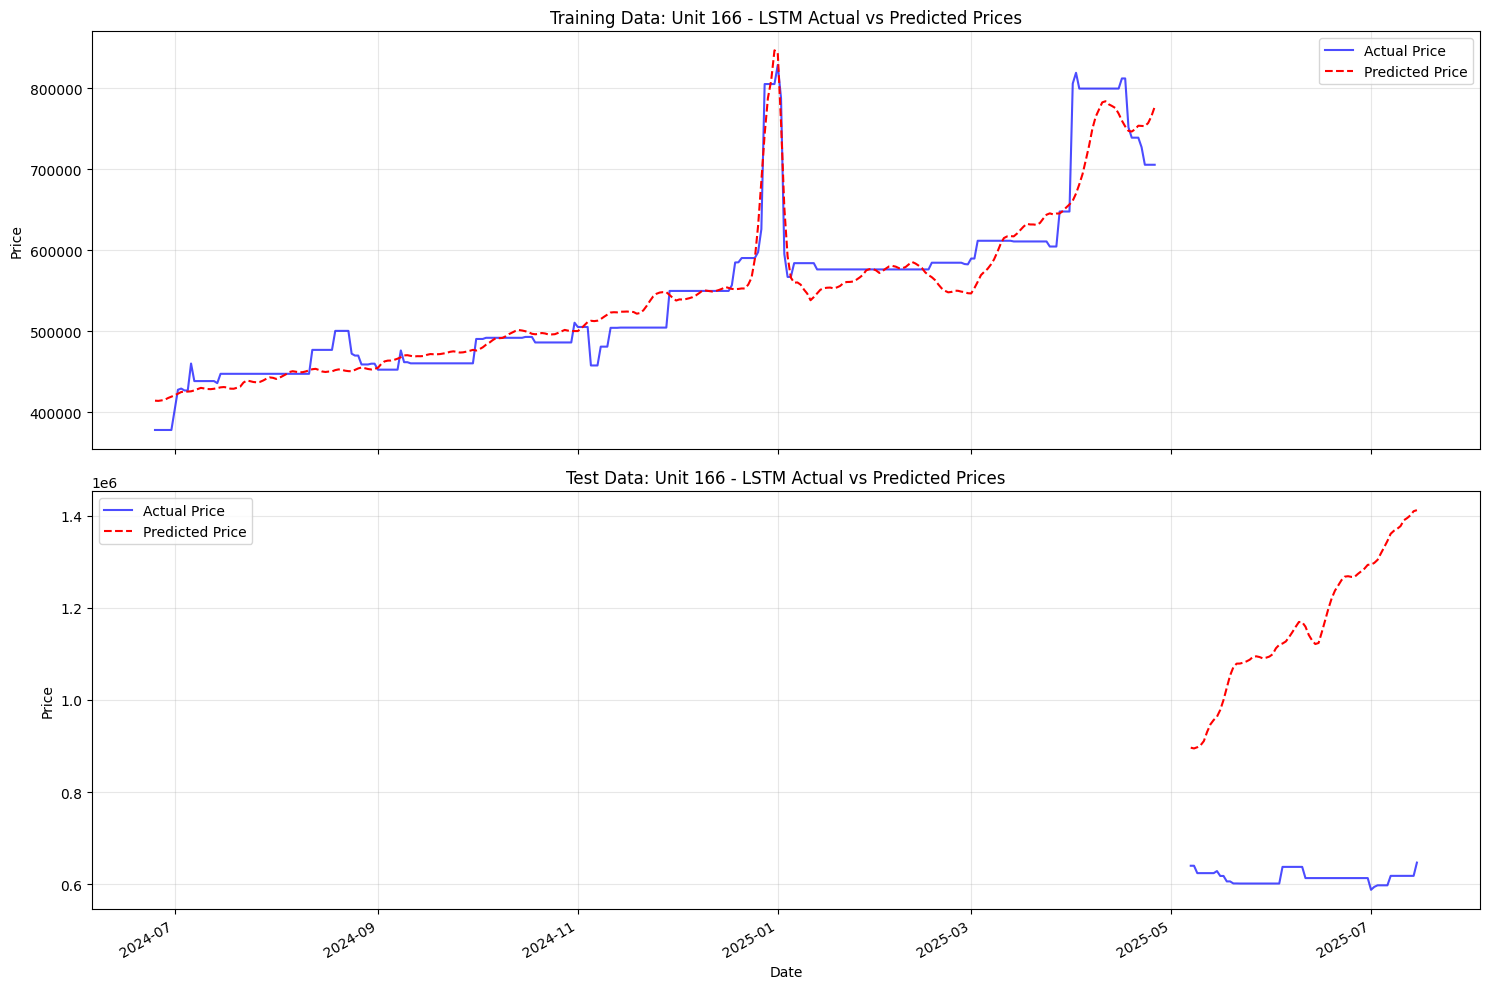

Plotting predictions on the full unit DataFrame...


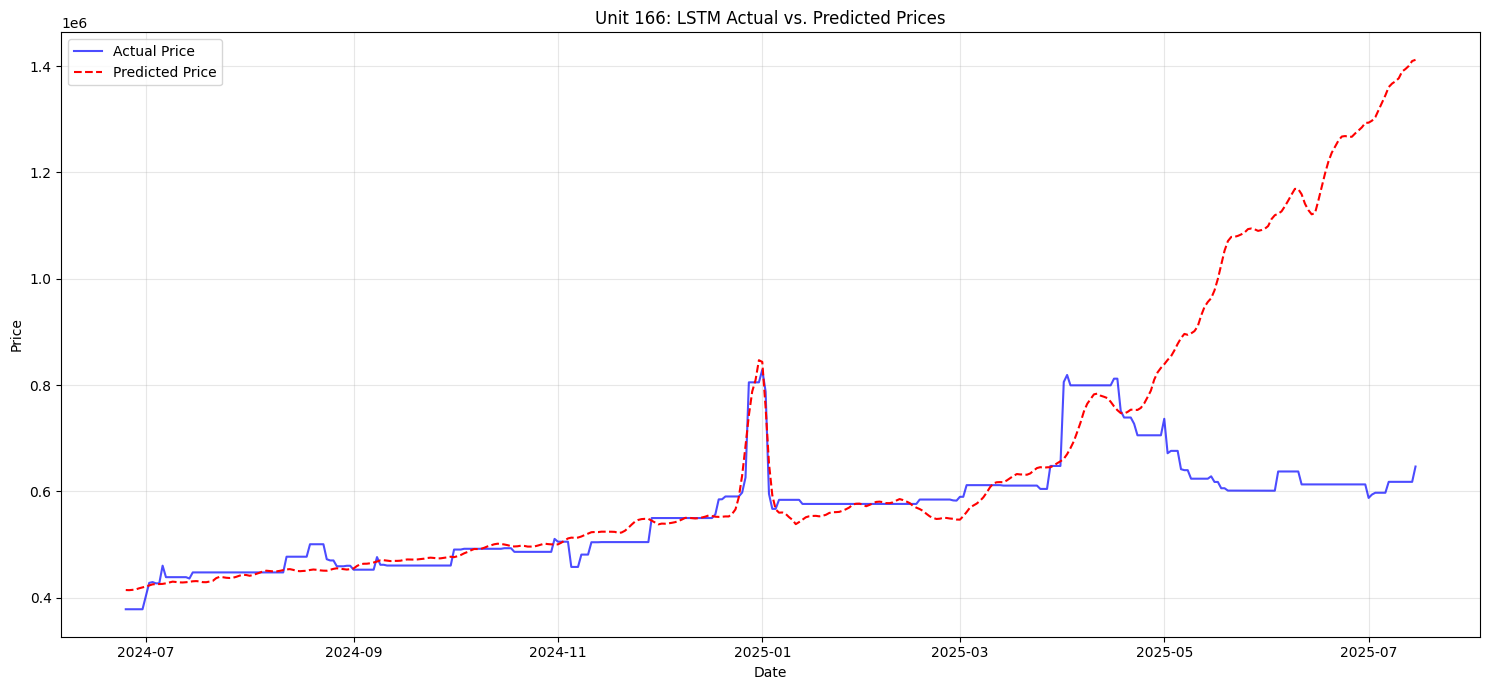


[Step 4/4] Pipeline finished for Unit 166.
--- End LSTM Pipeline ---


In [20]:
results_lstm_166 = run_lstm_pipeline(
    df_166,
    '166',
    test_size=0.2,
    sequence_length=10, 
    epochs=80,
)

In [45]:
def save_lstm_model(lstm_results, folder_path, model_name):
    """
    Save LSTM model state dictionary, feature scaler, target scaler, and metadata.
    """
    if not os.path.exists(folder_path):
        os.makedirs(folder_path)
        print(f"Created directory: {folder_path}")

    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    model_file_path = os.path.join(folder_path, f"{model_name}_model_state_dict.pth") 
    feature_scaler_path = os.path.join(folder_path, f"{model_name}_feature_scaler.pkl")
    target_scaler_path = os.path.join(folder_path, f"{model_name}_target_scaler.pkl")
    metadata_path = os.path.join(folder_path, f"{model_name}_metadata.json")

    model = lstm_results.get('model')
    feature_scaler = lstm_results.get('feature_scaler')
    target_scaler = lstm_results.get('target_scaler')
    sequence_length = lstm_results.get('sequence_length') 

    saved_paths = {}

    if model and isinstance(model, torch.nn.Module):
        try:
            torch.save(model.state_dict(), model_file_path)
            saved_paths['model_state_dict'] = model_file_path
            print(f"Model state dictionary successfully saved to {model_file_path}")
        except Exception as e:
            print(f"Error saving model state dictionary: {e}")
    else:
        print("Error: 'model' not found or is not a PyTorch Module in lstm_results.")

    if feature_scaler:
        try:
            with open(feature_scaler_path, 'wb') as f:
                pickle.dump(feature_scaler, f)
            saved_paths['feature_scaler'] = feature_scaler_path
            print(f"Feature scaler successfully saved to {feature_scaler_path}")
        except Exception as e:
            print(f"Error saving feature scaler: {e}")
    else:
        print("Warning: 'feature_scaler' not found in lstm_results.")

    if target_scaler:
        try:
            with open(target_scaler_path, 'wb') as f:
                pickle.dump(target_scaler, f)
            saved_paths['target_scaler'] = target_scaler_path
            print(f"Target scaler successfully saved to {target_scaler_path}")
        except Exception as e:
            print(f"Error saving target scaler: {e}")
    else:
        print("Warning: 'target_scaler' not found in lstm_results.")

    if model and sequence_length is not None:
         metadata = {
             'sequence_length': sequence_length,
             'input_dim': getattr(model, 'lstm', None).input_size if hasattr(model, 'lstm') else None,
             'hidden_dim': getattr(model, 'hidden_dim', None),
             'num_layers': getattr(model, 'num_layers', None),
             'dropout': getattr(getattr(model, 'dropout', None), 'p', None) if hasattr(model, 'dropout') else None,
             'feature_names_in': list(getattr(feature_scaler, 'feature_names_in_', [])) if feature_scaler else [], 
             'saved_timestamp': timestamp
         }
         try:
             with open(metadata_path, 'w') as f:
                 json.dump(metadata, f, indent=4)
             saved_paths['metadata'] = metadata_path
             print(f"Model metadata saved to {metadata_path}")
         except Exception as e:
             print(f"Error saving metadata: {e}")
    else:
         print("Warning: Could not save metadata (model or sequence_length missing).")


    return saved_paths

In [24]:
save_lstm_model(results_lstm_166, '../TrainedModels/LSTMModels', 'lstm_model_166')
save_lstm_model(results_lstm_167, '../TrainedModels/LSTMModels', 'lstm_model_167')

Created directory: ../TrainedModels/LSTMModels
Model state dictionary successfully saved to ../TrainedModels/LSTMModels\lstm_model_166_model_state_dict.pth
Feature scaler successfully saved to ../TrainedModels/LSTMModels\lstm_model_166_feature_scaler.pkl
Target scaler successfully saved to ../TrainedModels/LSTMModels\lstm_model_166_target_scaler.pkl
Model metadata saved to ../TrainedModels/LSTMModels\lstm_model_166_metadata.json
Model state dictionary successfully saved to ../TrainedModels/LSTMModels\lstm_model_167_model_state_dict.pth
Feature scaler successfully saved to ../TrainedModels/LSTMModels\lstm_model_167_feature_scaler.pkl
Target scaler successfully saved to ../TrainedModels/LSTMModels\lstm_model_167_target_scaler.pkl
Model metadata saved to ../TrainedModels/LSTMModels\lstm_model_167_metadata.json


{'model_state_dict': '../TrainedModels/LSTMModels\\lstm_model_167_model_state_dict.pth',
 'feature_scaler': '../TrainedModels/LSTMModels\\lstm_model_167_feature_scaler.pkl',
 'target_scaler': '../TrainedModels/LSTMModels\\lstm_model_167_target_scaler.pkl',
 'metadata': '../TrainedModels/LSTMModels\\lstm_model_167_metadata.json'}

In [46]:
def load_lstm_model(folder_path, model_name, device='cpu'):
    """
    Load LSTM model state dictionary, feature scaler, target scaler, and metadata.
    """
    model_file_path = os.path.join(folder_path, f"{model_name}_model_state_dict.pth")
    feature_scaler_path = os.path.join(folder_path, f"{model_name}_feature_scaler.pkl")
    target_scaler_path = os.path.join(folder_path, f"{model_name}_target_scaler.pkl")
    metadata_path = os.path.join(folder_path, f"{model_name}_metadata.json")

    loaded_components = {}
    model = None
    feature_scaler = None
    target_scaler = None
    metadata = None

    if os.path.exists(metadata_path):
        try:
            with open(metadata_path, 'r') as f:
                metadata = json.load(f)
            loaded_components['metadata'] = metadata
            print(f"Metadata successfully loaded from {metadata_path}")
        except Exception as e:
            print(f"Error loading metadata from {metadata_path}: {e}")
            return None 
    else:
        print(f"Error: Metadata file not found at {metadata_path}")
        return None

    if metadata:
        try:
            model = LSTMModel(
                input_dim=metadata['input_dim'],
                hidden_dim=metadata.get('hidden_dim', 80), 
                num_layers=metadata.get('num_layers', 2),
                dropout=metadata.get('dropout', 0.2)
            ).to(device)
            print(f"LSTMModel instantiated with parameters from metadata.")
        except NameError:
             print("Error: LSTMModel class definition not found. Please ensure it's defined.")
             return None
        except KeyError as e:
            print(f"Error: Missing essential key in metadata for model instantiation: {e}")
            return None
        except Exception as e:
            print(f"Error instantiating LSTMModel: {e}")
            return None

    if model and os.path.exists(model_file_path):
        try:
            model.load_state_dict(torch.load(model_file_path, map_location=device))
            model.eval() 
            loaded_components['model'] = model
            print(f"Model state dictionary successfully loaded from {model_file_path} onto {device}")
        except Exception as e:
            print(f"Error loading model state dictionary from {model_file_path}: {e}")

    elif not os.path.exists(model_file_path):
         print(f"Warning: Model state dictionary file not found at {model_file_path}")
    
    elif not model:
         print("Warning: Model could not be instantiated, skipping state dict loading.")


    if os.path.exists(feature_scaler_path):
        try:
            with open(feature_scaler_path, 'rb') as f:
                feature_scaler = pickle.load(f)
            loaded_components['feature_scaler'] = feature_scaler
            print(f"Feature scaler successfully loaded from {feature_scaler_path}")
        except Exception as e:
            print(f"Error loading feature scaler from {feature_scaler_path}: {e}")
    else:
        print(f"Warning: Feature scaler file not found at {feature_scaler_path}")

    if os.path.exists(target_scaler_path):
        try:
            with open(target_scaler_path, 'rb') as f:
                target_scaler = pickle.load(f)
            loaded_components['target_scaler'] = target_scaler
            print(f"Target scaler successfully loaded from {target_scaler_path}")
        except Exception as e:
            print(f"Error loading target scaler from {target_scaler_path}: {e}")
    else:
        print(f"Warning: Target scaler file not found at {target_scaler_path}")

    if 'model' not in loaded_components or 'feature_scaler' not in loaded_components or 'target_scaler' not in loaded_components:
        print("\nWarning: Not all essential components (model, feature_scaler, target_scaler) could be loaded.")
        return None

    print("\nLoading process finished.")
    return loaded_components

In [50]:
load_model_lstm_166 = load_lstm_model('../TrainedModels/LSTMModels', 'lstm_model_166', device='cuda' if torch.cuda.is_available() else 'cpu')
load_model_lstm_167 = load_lstm_model('../TrainedModels/LSTMModels', 'lstm_model_167', device='cuda' if torch.cuda.is_available() else 'cpu')

Metadata successfully loaded from ../TrainedModels/LSTMModels\lstm_model_166_metadata.json
LSTMModel instantiated with parameters from metadata.
Model state dictionary successfully loaded from ../TrainedModels/LSTMModels\lstm_model_166_model_state_dict.pth onto cuda
Feature scaler successfully loaded from ../TrainedModels/LSTMModels\lstm_model_166_feature_scaler.pkl
Target scaler successfully loaded from ../TrainedModels/LSTMModels\lstm_model_166_target_scaler.pkl

Loading process finished.
Metadata successfully loaded from ../TrainedModels/LSTMModels\lstm_model_167_metadata.json
LSTMModel instantiated with parameters from metadata.
Model state dictionary successfully loaded from ../TrainedModels/LSTMModels\lstm_model_167_model_state_dict.pth onto cuda
Feature scaler successfully loaded from ../TrainedModels/LSTMModels\lstm_model_167_feature_scaler.pkl
Target scaler successfully loaded from ../TrainedModels/LSTMModels\lstm_model_167_target_scaler.pkl

Loading process finished.


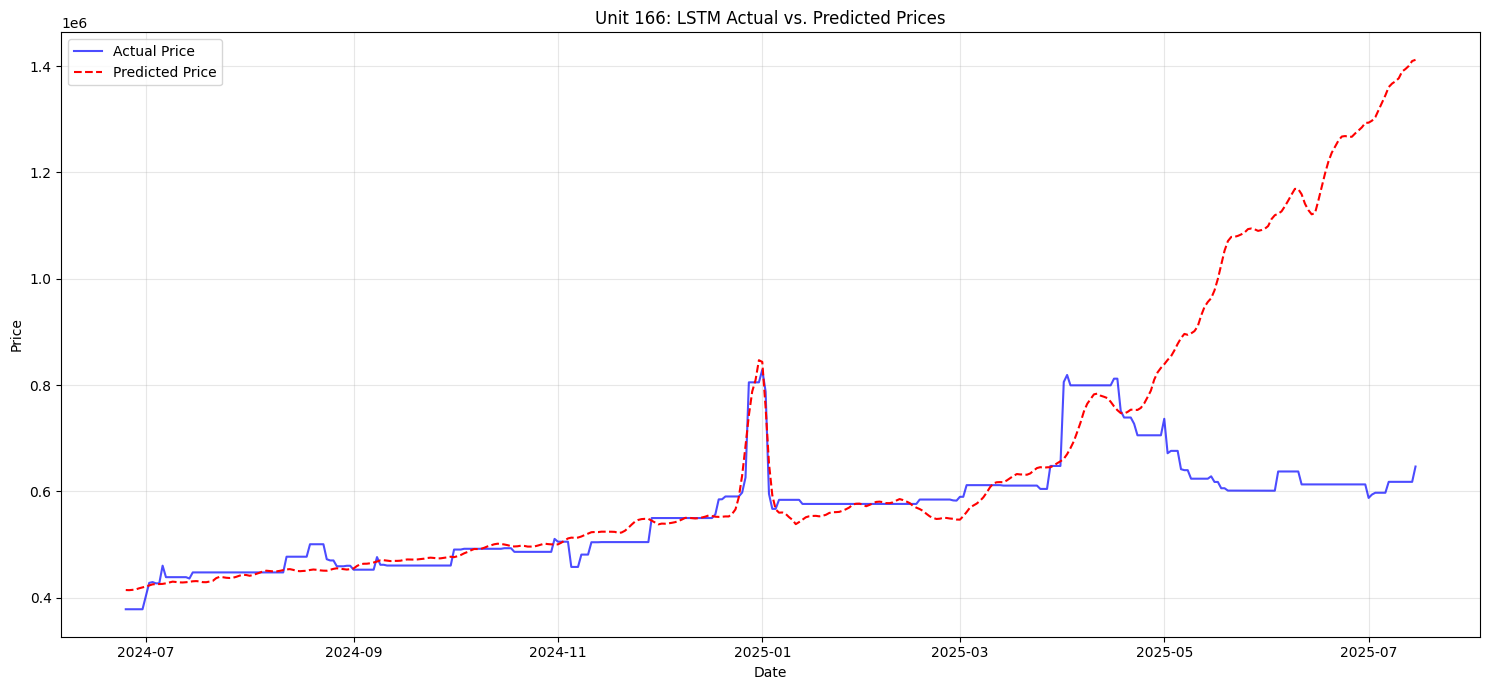

In [51]:
plot_lstm_predictions_on_dataframe(
    df=df_166,
    unit_id='166',
    model=load_model_lstm_166['model'],
    feature_scaler=load_model_lstm_166['feature_scaler'],
    target_scaler=load_model_lstm_166['target_scaler'],
    sequence_length=load_model_lstm_166['metadata']['sequence_length'],
    device='cuda' if torch.cuda.is_available() else 'cpu'
)

In [56]:

def predict_single_step_lstm(target_date_str, taux_occupation_target, df_history, loaded_model_data, unit_id, device):
    """
    Predicts the total_price for a single future date using a trained LSTM model.
    Requires historical data up to the day before the target date to form the input sequence.
    """
    print(f"\n--- Predicting for Unit {unit_id} on {target_date_str} ---")
    try:
        model = loaded_model_data.get('model')
        feature_scaler = loaded_model_data.get('feature_scaler')
        target_scaler = loaded_model_data.get('target_scaler')
        metadata = loaded_model_data.get('metadata')

        if not all([model, feature_scaler, target_scaler, metadata]):
            print("Error: Missing model, scalers, or metadata in loaded_model_data.")
            return None

        sequence_length = metadata.get('sequence_length')
        if sequence_length is None or not isinstance(sequence_length, int) or sequence_length <= 0:
            print(f"Error: Invalid 'sequence_length' ({sequence_length}) found in metadata.")
            return None

        try:
            target_date = pd.to_datetime(target_date_str)
        except ValueError:
            print(f"Error: Invalid target_date_str format: {target_date_str}. Use 'YYYY-MM-DD'.")
            return None

        target_features = {
            'dayofweek': target_date.dayofweek,
            'month': target_date.month,
            'year': target_date.year,
            'dayofyear': target_date.dayofyear,
            'weekofyear': pd.Int64Dtype().type(target_date.isocalendar().week),
            f'taux_occupation_{unit_id}': taux_occupation_target

        }
        target_row = pd.DataFrame([target_features], index=[target_date])
        print(f"Generated features for target date: {target_features}")

        if not isinstance(df_history.index, pd.DatetimeIndex):
             print("Error: df_history must have a DatetimeIndex.")
             return None
        df_history = df_history.sort_index()

        last_hist_date_needed = target_date - timedelta(days=1)
        first_hist_date_needed = last_hist_date_needed - timedelta(days=sequence_length - 2) 

        print(f"Fetching history from {first_hist_date_needed.date()} to {last_hist_date_needed.date()}")

        historical_sequence_df = df_history.loc[first_hist_date_needed : last_hist_date_needed]

        if len(historical_sequence_df) < sequence_length - 1:
            print(f"Error: Not enough historical data points found ({len(historical_sequence_df)}) between "
                  f"{first_hist_date_needed.date()} and {last_hist_date_needed.date()}. "
                  f"Need {sequence_length - 1}.")
            return None
        elif len(historical_sequence_df) > sequence_length - 1:
             print(f"Warning: Found more data points ({len(historical_sequence_df)}) than needed ({sequence_length - 1}). Using the latest ones.")
             historical_sequence_df = historical_sequence_df.iloc[-(sequence_length - 1):]


        input_sequence_df = pd.concat([historical_sequence_df, target_row])

        feature_order = metadata.get('feature_names_in') 
        if not feature_order and hasattr(feature_scaler, 'feature_names_in_'):
             feature_order = list(feature_scaler.feature_names_in_) 
        elif not feature_order:
             print("Error: Cannot determine feature order. Missing 'feature_names_in' in metadata and scaler.")
             return None

        print(f"Expected feature order: {feature_order}")

        missing_cols = [col for col in feature_order if col not in input_sequence_df.columns]
        if missing_cols:
            print(f"Error: Missing required feature columns in combined input data: {missing_cols}")
            return None

        try:
            input_sequence_df = input_sequence_df[feature_order]
        except Exception as e:
            print(f"Error reordering columns: {e}")
            return None

        if input_sequence_df.isnull().values.any():
             print("Error: NaNs found in the input sequence before scaling:")
             print(input_sequence_df[input_sequence_df.isnull().any(axis=1)])
             return None

        print(f"Scaling sequence of shape: {input_sequence_df.shape}")
        try:
            input_sequence_scaled = feature_scaler.transform(input_sequence_df)

        except ValueError as e:
             print(f"Error scaling input sequence. Check feature mismatch or dtype issues: {e}")
             print("Input DataFrame dtypes:\n", input_sequence_df.dtypes)
             return None

        except Exception as e:
             print(f"Error during scaling: {e}")
             return None

        input_tensor = torch.tensor(input_sequence_scaled, dtype=torch.float32).unsqueeze(0).to(device)
        print(f"Input tensor shape: {input_tensor.shape}")

        model.eval()
        with torch.no_grad():
            prediction_scaled = model(input_tensor)
        print(f"Scaled prediction shape: {prediction_scaled.shape}")

        predicted_price = target_scaler.inverse_transform(prediction_scaled.cpu().numpy())

        final_prediction = predicted_price[0][0]

        print(f"Predicted price (Unit {unit_id}) for {target_date_str}: {final_prediction:.2f}")
        return final_prediction

    except Exception as e:
        print(f"An unexpected error occurred during prediction: {e}")
        traceback.print_exc() 
        return None

In [57]:
predict_single_step_lstm(
    target_date_str='2025-01-01',
    taux_occupation_target=17.45,
    df_history=df_166,
    loaded_model_data=load_model_lstm_166,
    unit_id='166',
    device='cuda' if torch.cuda.is_available() else 'cpu'
)


--- Predicting for Unit 166 on 2025-01-01 ---
Generated features for target date: {'dayofweek': 2, 'month': 1, 'year': 2025, 'dayofyear': 1, 'weekofyear': 1, 'taux_occupation_166': 17.45}
Fetching history from 2024-12-23 to 2024-12-31
Expected feature order: ['dayofweek', 'month', 'year', 'dayofyear', 'weekofyear', 'taux_occupation_166']
Scaling sequence of shape: (10, 6)
Input tensor shape: torch.Size([1, 10, 6])
Scaled prediction shape: torch.Size([1, 1])
Predicted price (Unit 166) for 2025-01-01: 757822.81


757822.8

In [61]:
def find_max_price_for_date_lstm(
    loaded_model_data, 
    target_date_str, 
    unit_id, 
    df_history, 
    device, 
    min_taux=0.0, 
    max_taux=95.0, 
    step=0.01
):
    """
    Finds the taux_occupation that maximizes the predicted price for a single date
    using a trained LSTM model by iterating through a range of taux_occupation values.

    Args:
        loaded_model_data (dict): Dictionary containing the loaded LSTM model, scalers, and metadata.
        target_date_str (str): The target date for prediction in 'YYYY-MM-DD' format.
        unit_id (str): The identifier for the unit (e.g., '166', '167').
        df_history (pd.DataFrame): DataFrame containing historical data for the unit.
                                   Must have a DatetimeIndex and include necessary features.
        device (str): Device to run LSTM model on ('cpu' or 'cuda').
        min_taux (float): Minimum taux_occupation to test.
        max_taux (float): Maximum taux_occupation to test.
        step (float): Step for iterating taux_occupation.

    """
    best_taux_occupation = None
    max_predicted_price = -float('inf')

    print(f"\nSearching for optimal taux_occupation for LSTM model (unit {unit_id}) on {target_date_str}...")
    print(f"Range: {min_taux}-{max_taux}, step: {step}")

    num_steps = int((max_taux - min_taux) / step) + 1
    taux_values = np.linspace(min_taux, max_taux, num_steps)

    for taux in tqdm(taux_values, desc="Testing LSTM taux_occupation values"):
        predicted_price = predict_single_step_lstm(
            target_date_str=target_date_str,
            taux_occupation_target=taux,
            df_history=df_history, 
            loaded_model_data=loaded_model_data,
            unit_id=unit_id,
            device=device
        )
        
        if predicted_price is not None:
            if predicted_price > max_predicted_price:
                max_predicted_price = predicted_price
                best_taux_occupation = taux
    
    if best_taux_occupation is not None:
        print(f"\nLSTM Search complete. Optimal taux_occupation: {best_taux_occupation:.2f} -> Max Price: {max_predicted_price:.2f}")
        return best_taux_occupation, max_predicted_price
    else:
        print("LSTM Search complete. No valid predictions found.")
        return None, None

In [68]:
best_taux_occupation, max_predicted_price = find_max_price_for_date_lstm(
    loaded_model_data=load_model_lstm_166,
    target_date_str='2025-06-20',
    unit_id='166',
    df_history=df_166,
    device='cuda' if torch.cuda.is_available() else 'cpu',
    min_taux=0.0,
    max_taux=90.0,
    step=0.1
)


Searching for optimal taux_occupation for LSTM model (unit 166) on 2025-06-20...
Range: 0.0-90.0, step: 0.1


Testing LSTM taux_occupation values:   1%|▏         | 12/901 [00:00<00:07, 116.49it/s]


--- Predicting for Unit 166 on 2025-06-20 ---
Generated features for target date: {'dayofweek': 4, 'month': 6, 'year': 2025, 'dayofyear': 171, 'weekofyear': 25, 'taux_occupation_166': 0.0}
Fetching history from 2025-06-11 to 2025-06-19
Expected feature order: ['dayofweek', 'month', 'year', 'dayofyear', 'weekofyear', 'taux_occupation_166']
Scaling sequence of shape: (10, 6)
Input tensor shape: torch.Size([1, 10, 6])
Scaled prediction shape: torch.Size([1, 1])
Predicted price (Unit 166) for 2025-06-20: 1248639.62

--- Predicting for Unit 166 on 2025-06-20 ---
Generated features for target date: {'dayofweek': 4, 'month': 6, 'year': 2025, 'dayofyear': 171, 'weekofyear': 25, 'taux_occupation_166': 0.1}
Fetching history from 2025-06-11 to 2025-06-19
Expected feature order: ['dayofweek', 'month', 'year', 'dayofyear', 'weekofyear', 'taux_occupation_166']
Scaling sequence of shape: (10, 6)
Input tensor shape: torch.Size([1, 10, 6])
Scaled prediction shape: torch.Size([1, 1])
Predicted price (U

Testing LSTM taux_occupation values:   3%|▎         | 27/901 [00:00<00:06, 130.69it/s]

Predicted price (Unit 166) for 2025-06-20: 1248307.50


...

Input tensor shape: torch.Size([1, 10, 6])
Scaled prediction shape: torch.Size([1, 1])
Predicted price (Unit 166) for 2025-06-20: 1240972.12

--- Predicting for Unit 166 on 2025-06-20 ---
Generated features for target date: {'dayofweek': 4, 'month': 6, 'year': 2025, 'dayofyear': 171, 'weekofyear': 25, 'taux_occupation_166': 80.7}
Fetching history from 2025-06-11 to 2025-06-19
Expected feature order: ['dayofweek', 'month', 'year', 'dayofyear', 'weekofyear', 'taux_occupation_166']
Scaling sequence of shape: (10, 6)
Input tensor shape: torch.Size([1, 10, 6])
Scaled prediction shape: torch.Size([1, 1])
Predicted price (Unit 166) for 2025-06-20: 1240965.75

--- Predicting for Unit 166 on 2025-06-20 ---
Generated features for target date: {'dayofweek': 4, 'month': 6, 'year': 2025, 'dayofyear': 171, 'weekofyear': 25, 'taux_occupation_166': 80.80000000000001}
Fetching history from 2025-06-11 to 2025-06-19
Expected feature order: ['dayofweek', 'month', 'year', 'dayofyear', 'weekofyear', 'taux_o

Testing LSTM taux_occupation values:  96%|█████████▌| 864/901 [00:05<00:00, 171.23it/s]

Input tensor shape: torch.Size([1, 10, 6])
Scaled prediction shape: torch.Size([1, 1])
Predicted price (Unit 166) for 2025-06-20: 1240743.25

--- Predicting for Unit 166 on 2025-06-20 ---
Generated features for target date: {'dayofweek': 4, 'month': 6, 'year': 2025, 'dayofyear': 171, 'weekofyear': 25, 'taux_occupation_166': 84.4}
Fetching history from 2025-06-11 to 2025-06-19
Expected feature order: ['dayofweek', 'month', 'year', 'dayofyear', 'weekofyear', 'taux_occupation_166']
Scaling sequence of shape: (10, 6)
Input tensor shape: torch.Size([1, 10, 6])
Scaled prediction shape: torch.Size([1, 1])
Predicted price (Unit 166) for 2025-06-20: 1240737.25

--- Predicting for Unit 166 on 2025-06-20 ---
Generated features for target date: {'dayofweek': 4, 'month': 6, 'year': 2025, 'dayofyear': 171, 'weekofyear': 25, 'taux_occupation_166': 84.5}
Fetching history from 2025-06-11 to 2025-06-19
Expected feature order: ['dayofweek', 'month', 'year', 'dayofyear', 'weekofyear', 'taux_occupation_166

Testing LSTM taux_occupation values: 100%|██████████| 901/901 [00:05<00:00, 159.21it/s]

Input tensor shape: torch.Size([1, 10, 6])
Scaled prediction shape: torch.Size([1, 1])
Predicted price (Unit 166) for 2025-06-20: 1240547.50

--- Predicting for Unit 166 on 2025-06-20 ---
Generated features for target date: {'dayofweek': 4, 'month': 6, 'year': 2025, 'dayofyear': 171, 'weekofyear': 25, 'taux_occupation_166': 87.7}
Fetching history from 2025-06-11 to 2025-06-19
Expected feature order: ['dayofweek', 'month', 'year', 'dayofyear', 'weekofyear', 'taux_occupation_166']
Scaling sequence of shape: (10, 6)
Input tensor shape: torch.Size([1, 10, 6])
Scaled prediction shape: torch.Size([1, 1])
Predicted price (Unit 166) for 2025-06-20: 1240541.62

--- Predicting for Unit 166 on 2025-06-20 ---
Generated features for target date: {'dayofweek': 4, 'month': 6, 'year': 2025, 'dayofyear': 171, 'weekofyear': 25, 'taux_occupation_166': 87.80000000000001}
Fetching history from 2025-06-11 to 2025-06-19
Expected feature order: ['dayofweek', 'month', 'year', 'dayofyear', 'weekofyear', 'taux_o

### train The `XGBoost model`

In [69]:
def train_evaluate_xgboost_model(X_train, X_test, y_train, y_test, target_col,
                                 n_estimators=1000, learning_rate=0.01, max_depth=5,
                                 subsample=0.8, colsample_bytree=0.8):
    """
    Trains an XGBoost Regressor model, evaluates it, and returns results.
    (Simplified version with early stopping and additional params removed)

    Args:
        X_train (pd.DataFrame): Training features
        X_test (pd.DataFrame): Testing features
        y_train (pd.Series): Training target values
        y_test (pd.Series): Testing target values
        target_col (str): Name of the target column
        n_estimators (int): Number of boosting rounds
        learning_rate (float): Learning rate
        max_depth (int): Maximum tree depth
        subsample (float): Subsample ratio of training instances
        colsample_bytree (float): Subsample ratio of columns when constructing each tree
    """
    print(f"\nTraining XGBoost model for target: {target_col}")
    print(f"Hyperparameters: n_estimators={n_estimators}, lr={learning_rate}, max_depth={max_depth}")
    print(f"Features used (X): {X_train.columns.tolist()}")
    print(f"Training set size: {X_train.shape[0]} samples")
    print(f"Testing set size: {X_test.shape[0]} samples")

    model = xgb.XGBRegressor(
        objective='reg:squarederror',
        n_estimators=n_estimators,
        learning_rate=learning_rate,
        max_depth=max_depth,
        subsample=subsample,
        colsample_bytree=colsample_bytree,
        random_state=42,
        n_jobs=-1
    )

    print("\nStarting Training...")
    model.fit(X_train, y_train)
    print("Training Finished.")

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    train_mae = mean_absolute_error(y_train, y_train_pred)
    test_mae = mean_absolute_error(y_test, y_test_pred)
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)

    print("\nModel Evaluation Metrics:")
    print(f"Train RMSE: {train_rmse:.2f}")
    print(f"Test RMSE: {test_rmse:.2f}")
    print(f"Train MAE: {train_mae:.2f}")
    print(f"Test MAE: {test_mae:.2f}")
    print(f"Train R²: {train_r2:.4f}")
    print(f"Test R²: {test_r2:.4f}")

    feature_importance = pd.DataFrame({
        'Feature': X_train.columns,
        'Importance': model.feature_importances_
    }).sort_values('Importance', ascending=False)

    print("\nFeature Importance:")
    print(feature_importance)

    return {
        'model': model,
        'X_train': X_train,
        'X_test': X_test,
        'y_train': y_train,
        'y_test': y_test,
        'y_train_pred': y_train_pred,
        'y_test_pred': y_test_pred,
        'metrics': {
            'train_rmse': train_rmse,
            'test_rmse': test_rmse,
            'train_mae': train_mae,
            'test_mae': test_mae,
            'train_r2': train_r2,
            'test_r2': test_r2
        },
        'feature_importance': feature_importance
    }

def run_xgboost_pipeline(df_unit, unit_id, test_size=0.2,
                        n_estimators=1000, learning_rate=0.01, max_depth=5,
                        subsample=0.8, colsample_bytree=0.8):
    """
    Runs the complete XGBoost training, evaluation, and plotting pipeline
    for a specific unit (simplified without additional parameters).
    """
    print(f"--- Starting XGBoost Pipeline for Unit {unit_id} ---")

    print(f"\n[Step 1/3] Splitting data with test_size={test_size}...")
    try:
        X_train, X_test, y_train, y_test, target_col = split_data_train_test(
            n_estimators= n_estimators, learning_rate=learning_rate, max_depth=max_depth,
            subsample=subsample, colsample_bytree=colsample_bytree,
            df=df_unit, unit_id=unit_id, test_size=test_size
        )

    except ValueError as e:
        print(f"Error during data splitting: {e}")
        return None

    except Exception as e:
         print(f"An unexpected error occurred during data splitting: {e}")
         return None

    print("\n[Step 2/3] Training and evaluating XGBoost model...")

    try:
        model_results = train_evaluate_xgboost_model(
            X_train, X_test, y_train, y_test, target_col
        )

    except Exception as e:
         print(f"An unexpected error occurred during training/evaluation: {e}")
         return None

    print("\n[Step 3/3] Plotting results...")
    
    try:
        print("Plotting predictions on train/test split...")
        plot_predictions_over_time(model_results, df_unit, unit_id)

        print("Plotting predictions on the full unit DataFrame...")
        plot_actual_vs_predicted(model_results['model'], df_unit, unit_id)

    except KeyError as e:
        print(f"Error during plotting: Missing key in model_results - {e}")
    
    except Exception as e:
        print(f"An unexpected error occurred during plotting: {e}")

    print(f"\nPipeline finished for Unit {unit_id}.")
    print("--- End XGBoost Pipeline ---")

    return model_results

### The **XGBoost** pipeline 

In [70]:
def train_evaluate_xgboost_model(X_train, X_test, y_train, y_test, target_col,
                                 n_estimators=1000, learning_rate=0.01, max_depth=5,
                                 subsample=0.8, colsample_bytree=0.8):
    """
    Trains an XGBoost Regressor model, evaluates it, and returns results.
    (Simplified version with early stopping and additional params removed)
    """
    print(f"\nTraining XGBoost model for target: {target_col}")
    print(f"Hyperparameters: n_estimators={n_estimators}, lr={learning_rate}, max_depth={max_depth}")
    print(f"Features used (X): {X_train.columns.tolist()}")
    print(f"Training set size: {X_train.shape[0]} samples")
    print(f"Testing set size: {X_test.shape[0]} samples")

    model = xgb.XGBRegressor(
        objective='reg:squarederror',
        n_estimators=n_estimators,
        learning_rate=learning_rate,
        max_depth=max_depth,
        subsample=subsample,
        colsample_bytree=colsample_bytree,
        random_state=42,
        n_jobs=-1
    )

    print("\nStarting Training...")
    model.fit(X_train, y_train)
    print("Training Finished.")

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    train_mae = mean_absolute_error(y_train, y_train_pred)
    test_mae = mean_absolute_error(y_test, y_test_pred)
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)

    print("\nModel Evaluation Metrics:")
    print(f"Train RMSE: {train_rmse:.2f}")
    print(f"Test RMSE: {test_rmse:.2f}")
    print(f"Train MAE: {train_mae:.2f}")
    print(f"Test MAE: {test_mae:.2f}")
    print(f"Train R²: {train_r2:.4f}")
    print(f"Test R²: {test_r2:.4f}")

    feature_importance = pd.DataFrame({
        'Feature': X_train.columns,
        'Importance': model.feature_importances_
    }).sort_values('Importance', ascending=False)

    print("\nFeature Importance:")
    print(feature_importance)

    return {
        'model': model,
        'X_train': X_train,
        'X_test': X_test,
        'y_train': y_train,
        'y_test': y_test,
        'y_train_pred': y_train_pred,
        'y_test_pred': y_test_pred,
        'metrics': {
            'train_rmse': train_rmse,
            'test_rmse': test_rmse,
            'train_mae': train_mae,
            'test_mae': test_mae,
            'train_r2': train_r2,
            'test_r2': test_r2
        },
        'feature_importance': feature_importance
    }

def run_xgboost_pipeline(df_unit, unit_id, test_size=0.2,
                        n_estimators=1000, learning_rate=0.01, max_depth=5,
                        subsample=0.8, colsample_bytree=0.8):
    """
    Runs the complete XGBoost training, evaluation, and plotting pipeline
    for a specific unit (simplified without additional parameters).
    """
    print(f"--- Starting XGBoost Pipeline for Unit {unit_id} ---")

    print(f"\n[Step 1/3] Splitting data with test_size={test_size}...")
    try:
        X_train, X_test, y_train, y_test, target_col = split_data_train_test(
            df=df_unit, unit_id=unit_id, test_size=test_size
        )

    except ValueError as e:
        print(f"Error during data splitting: {e}")
        return None

    except Exception as e:
         print(f"An unexpected error occurred during data splitting: {e}")
         return None

    print("\n[Step 2/3] Training and evaluating XGBoost model...")

    try:
        model_results = train_evaluate_xgboost_model(
            X_train, X_test, y_train, y_test, target_col
        )

    except Exception as e:
         print(f"An unexpected error occurred during training/evaluation: {e}")
         return None

    print("\n[Step 3/3] Plotting results...")
    
    try:
        print("Plotting predictions on train/test split...")
        plot_predictions_over_time(model_results, df_unit, unit_id)

        print("Plotting predictions on the full unit DataFrame...")
        plot_actual_vs_predicted(model_results['model'], df_unit, unit_id)

    except KeyError as e:
        print(f"Error during plotting: Missing key in model_results - {e}")
    
    except Exception as e:
        print(f"An unexpected error occurred during plotting: {e}")

    print(f"\nPipeline finished for Unit {unit_id}.")
    print("--- End XGBoost Pipeline ---")

    return model_results

--- Starting XGBoost Pipeline for Unit 166 ---

[Step 1/3] Splitting data with test_size=0.2...
split complete. Test size: 0.20
Training set range: 2024-06-15 00:00:00 to 2025-04-26 00:00:00 (316 samples)
Testing set range: 2025-04-27 00:00:00 to 2025-07-15 00:00:00 (80 samples)

[Step 2/3] Training and evaluating XGBoost model...

Training XGBoost model for target: total_price_166
Hyperparameters: n_estimators=1000, lr=0.01, max_depth=5
Features used (X): ['dayofweek', 'month', 'year', 'dayofyear', 'weekofyear', 'taux_occupation_166']
Training set size: 316 samples
Testing set size: 80 samples

Starting Training...
Training Finished.

Model Evaluation Metrics:
Train RMSE: 1916.63
Test RMSE: 135052.02
Train MAE: 1189.10
Test MAE: 117811.57
Train R²: 0.9997
Test R²: -20.3035

Feature Importance:
               Feature  Importance
2                 year    0.630211
1                month    0.176615
4           weekofyear    0.149820
3            dayofyear    0.036996
5  taux_occupation_

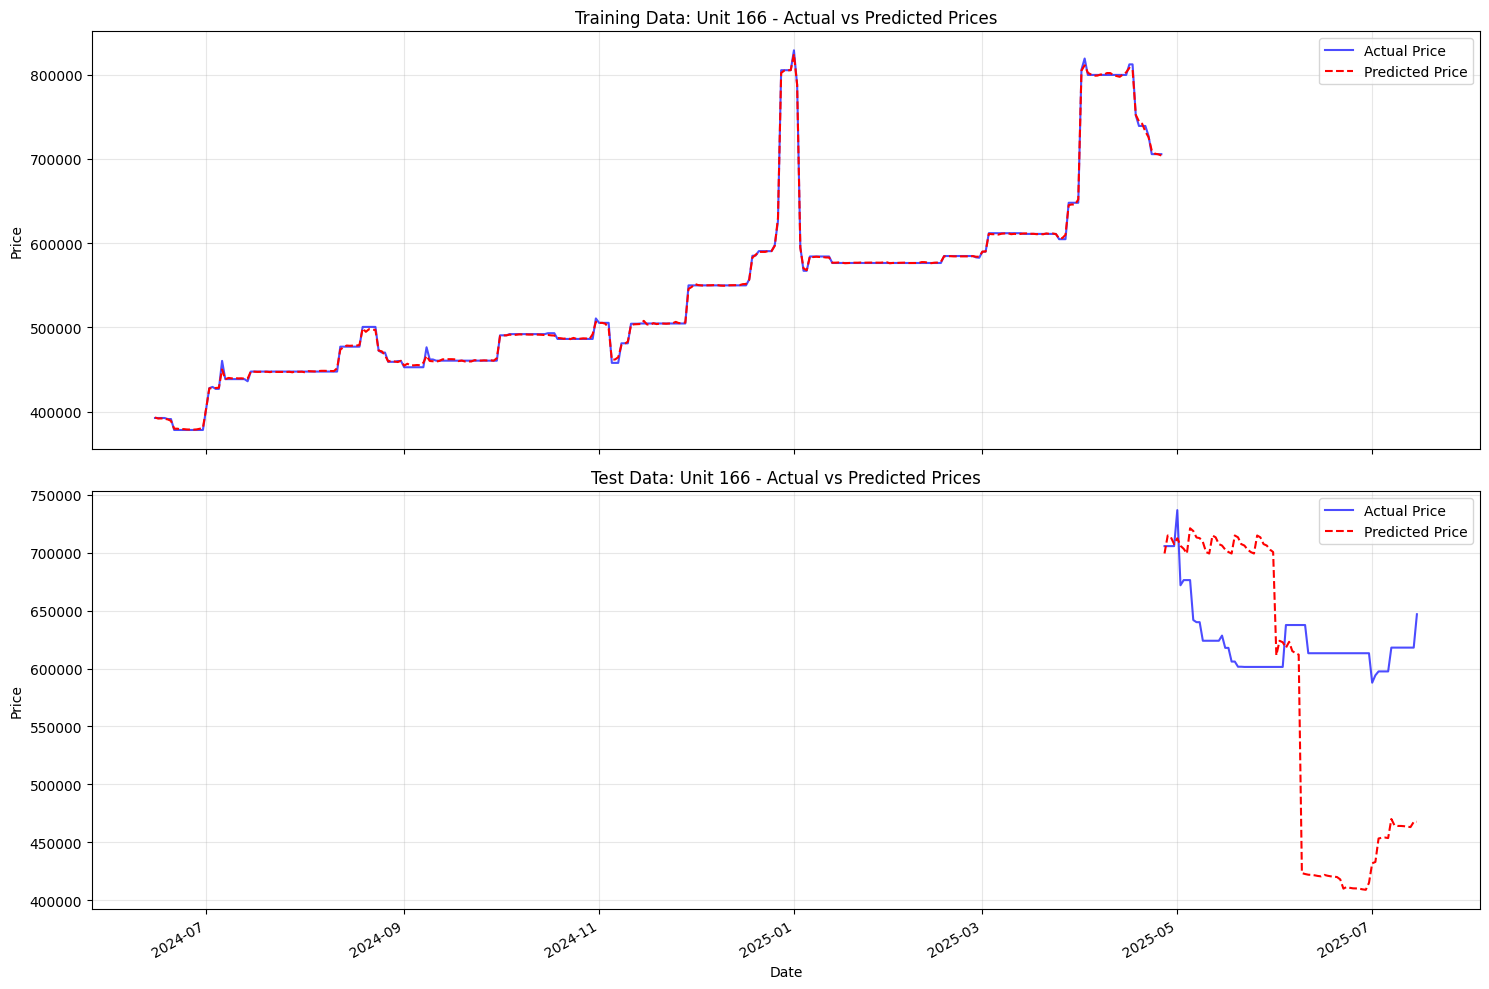

Plotting predictions on the full unit DataFrame...
Columns used for prediction: ['dayofweek', 'month', 'year', 'dayofyear', 'weekofyear', 'taux_occupation_166']


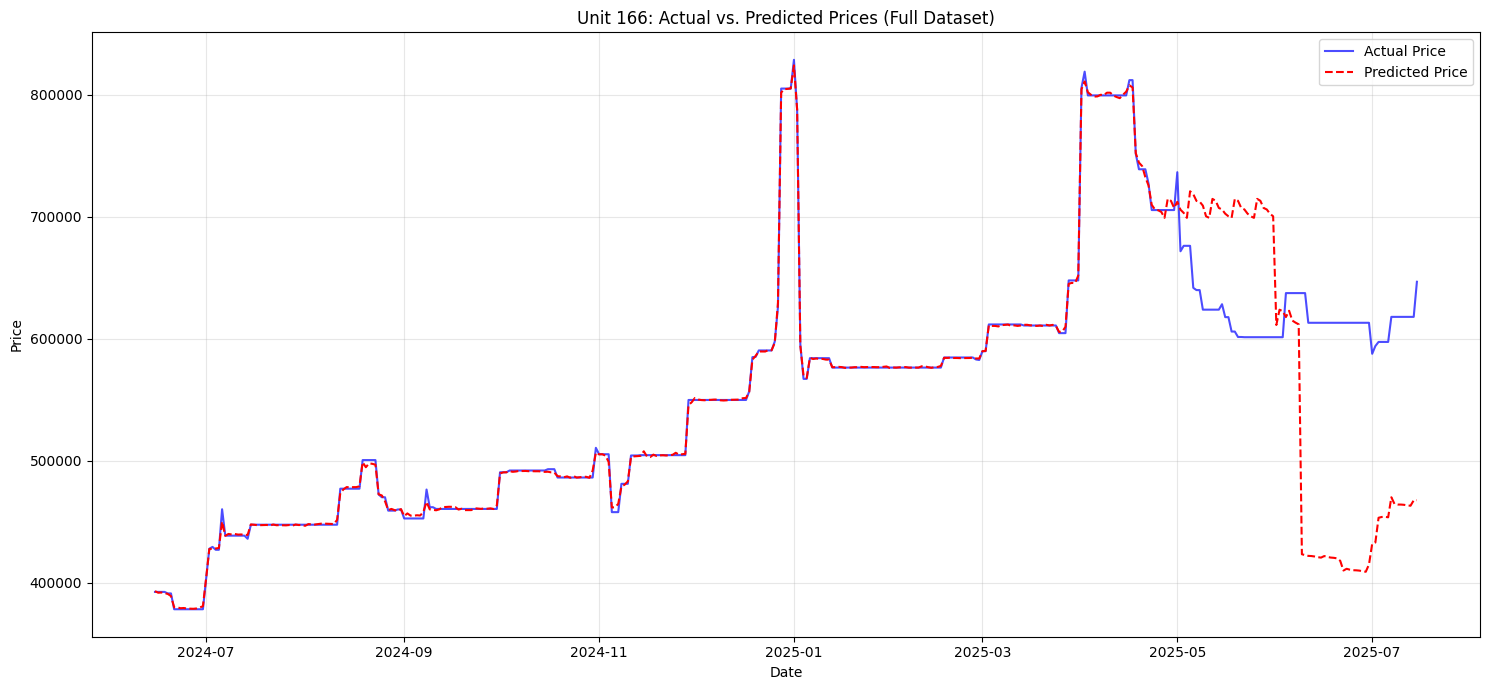


Pipeline finished for Unit 166.
--- End XGBoost Pipeline ---


In [21]:
xgb_results_166 = run_xgboost_pipeline(
    df_166,
    '166',
    test_size=0.2
)

--- Starting XGBoost Pipeline for Unit 167 ---

[Step 1/3] Splitting data with test_size=0.2...
split complete. Test size: 0.20
Training set range: 2024-06-15 00:00:00 to 2025-04-26 00:00:00 (316 samples)
Testing set range: 2025-04-27 00:00:00 to 2025-07-15 00:00:00 (80 samples)

[Step 2/3] Training and evaluating XGBoost model...

Training XGBoost model for target: total_price_167
Hyperparameters: n_estimators=1000, lr=0.01, max_depth=5
Features used (X): ['dayofweek', 'month', 'year', 'dayofyear', 'weekofyear', 'taux_occupation_167']
Training set size: 316 samples
Testing set size: 80 samples

Starting Training...
Training Finished.

Model Evaluation Metrics:
Train RMSE: 499.34
Test RMSE: 27753.09
Train MAE: 282.94
Test MAE: 24337.29
Train R²: 0.9981
Test R²: -33.9474

Feature Importance:
               Feature  Importance
5  taux_occupation_167    0.360942
2                 year    0.291873
1                month    0.137033
3            dayofyear    0.111165
4           weekofyear 

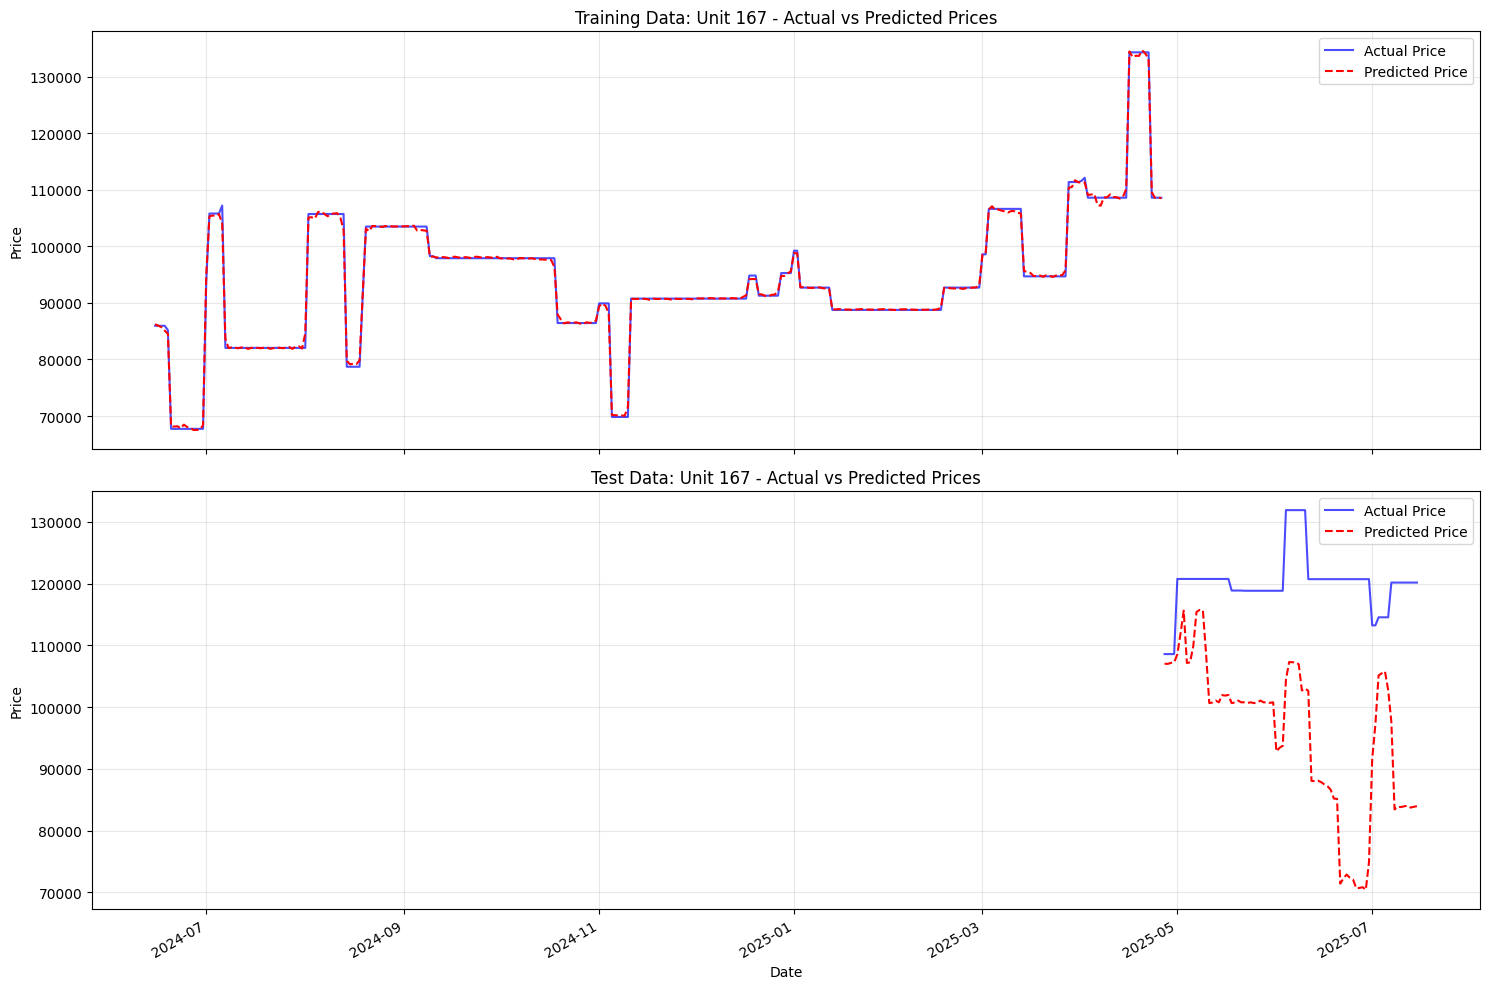

Plotting predictions on the full unit DataFrame...
Columns used for prediction: ['dayofweek', 'month', 'year', 'dayofyear', 'weekofyear', 'taux_occupation_167']


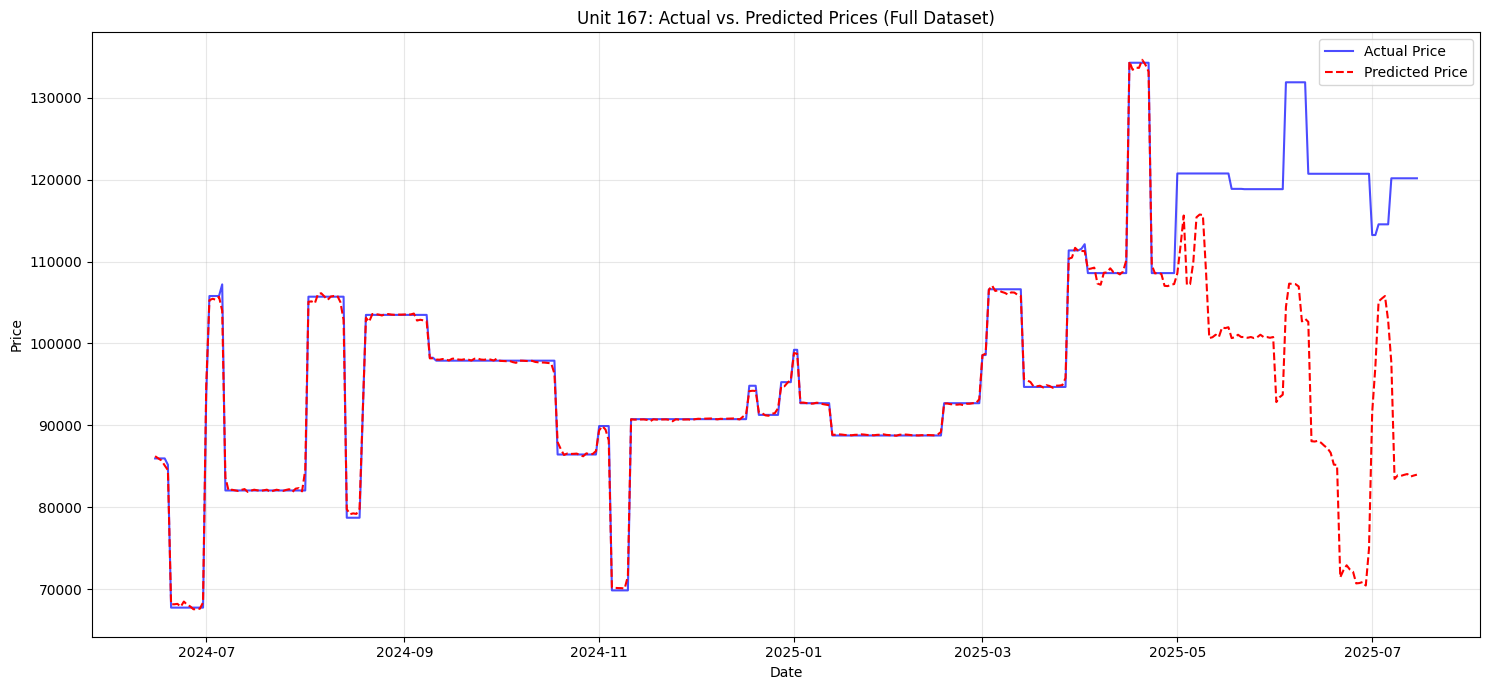


Pipeline finished for Unit 167.
--- End XGBoost Pipeline ---


In [20]:
xgb_results_167 = run_xgboost_pipeline(
    df_167,
    '167',
    test_size=0.2
)

In [23]:
def save_xgboost_model(xgb_results, folder_path, model_name):
    """
    Save only the XGBoost model using pickle to a specified folder path.
    """
    if not os.path.exists(folder_path):
        os.makedirs(folder_path)
        print(f"Created directory: {folder_path}")
    
    model_file_path = os.path.join(folder_path, f"{model_name}.pkl")
    
    model = xgb_results.get('model')
    if model is None:
        print("Error: No model found in the xgb_results dictionary")
        return None
    
    try:
        with open(model_file_path, 'wb') as f:
            pickle.dump(model, f)
        print(f"Model successfully saved to {model_file_path}")
        return model_file_path
    except Exception as e:
        print(f"Error saving model: {e}")
        return None

In [24]:
save_xgboost_model(xgb_results_166, '../TrainedModels/XGBoostModels', 'xgboost_model_166')
save_xgboost_model(xgb_results_167, '../TrainedModels/XGBoostModels', 'xgboost_model_167')

Model successfully saved to ../TrainedModels/XGBoostModels\xgboost_model_166.pkl
Model successfully saved to ../TrainedModels/XGBoostModels\xgboost_model_167.pkl


'../TrainedModels/XGBoostModels\\xgboost_model_167.pkl'

In [71]:
def load_xgboost_model(folder_path, model_name):
    """
    Load a pickled XGBoost model from a specified folder path.

    Args:
        folder_path (str): The directory where the model is saved.
        model_name (str): The name of the model file (without .pkl extension).
    """
    file_path = os.path.join(folder_path, f"{model_name}.pkl")
    
    if not os.path.exists(file_path):
        print(f"Error: Model file not found at {file_path}")
        return None
    
    try:
        with open(file_path, 'rb') as f:
            model = pickle.load(f)
        print(f"XGBoost model successfully loaded from {file_path}")
        return model
    except Exception as e:
        print(f"Error loading XGBoost model: {e}")
        return None

In [72]:
loaded_xgboost_model_166 = load_xgboost_model('../TrainedModels/XGBoostModels', 'xgboost_model_166')
loaded_xgboost_model_167 = load_xgboost_model('../TrainedModels/XGBoostModels', 'xgboost_model_167')

XGBoost model successfully loaded from ../TrainedModels/XGBoostModels\xgboost_model_166.pkl
XGBoost model successfully loaded from ../TrainedModels/XGBoostModels\xgboost_model_167.pkl


In [73]:
def predict_single_date_xgboost_model(model, target_date_str, unit_id, taux_occupation_target):
    """
    Predicts the total_price for a single future date using a trained XGBoost model.

    Args:
        model: The trained XGBoost model (e.g., xgb.XGBRegressor).
        target_date_str (str): The target date for prediction in 'YYYY-MM-DD' format.
        unit_id (str): The identifier for the unit (e.g., '166', '167').
        taux_occupation_target (float): The expected taux_occupation for the target date.
    """
    if model is None:
        print("Error: The XGBoost model provided is None.")
        return None

    try:
        target_date = pd.to_datetime(target_date_str)
    except ValueError:
        print(f"Error: Invalid target_date_str format: {target_date_str}. Please use 'YYYY-MM-DD'.")
        return None

    features = {
        'dayofweek': target_date.dayofweek,
        'month': target_date.month,
        'year': target_date.year,
        'dayofyear': target_date.dayofyear,
        'weekofyear': int(target_date.isocalendar().week),  
        f'taux_occupation_{unit_id}': taux_occupation_target
    }

    if hasattr(model, 'feature_names_in_'):
        feature_order = model.feature_names_in_
    else:
        feature_order = ['dayofweek', 'month', 'year', 'dayofyear', 'weekofyear', f'taux_occupation_{unit_id}']
        print(f"Warning: Model does not have 'feature_names_in_'. Using default feature order: {feature_order}")


    try:
        input_df = pd.DataFrame([features], columns=feature_order)
    except Exception as e:
        print(f"Error creating DataFrame for prediction: {e}")
        return None
        
    for col in feature_order:
        if col not in input_df.columns:
            print(f"Error: Missing expected feature '{col}' in the generated input for XGBoost.")
            print(f"Available columns: {list(input_df.columns)}")
            print(f"Input data: {features}")
            return None
            
    print(f"\nPredicting with XGBoost for Unit {unit_id} on {target_date_str} with features:")
    print(input_df)

    try:
        prediction = model.predict(input_df)
        return float(prediction[0])  
    except Exception as e:
        print(f"Error during XGBoost prediction: {e}")
        if hasattr(model, 'feature_names_in_'):
            print(f"Model was trained/expects features: {model.feature_names_in_}")
        print(f"Input features provided: {input_df.columns.tolist()}")
        return None

In [74]:
predict_single_date_xgboost_model(
    model=loaded_xgboost_model_166,
    target_date_str='2025-01-01',
    unit_id='166',
    taux_occupation_target=17.45
)


Predicting with XGBoost for Unit 166 on 2025-01-01 with features:
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_166
0          2      1  2025          1           1                17.45


824185.625

In [75]:
def find_max_price_for_date_xgboost(model, target_date_str, unit_id, min_taux=0.0, max_taux=95.0, step=0.01):
    """
    Finds the taux_occupation that maximizes the predicted price for a single date
    using a trained XGBoost model by iterating through a range of taux_occupation values.

    Args:
        model: The trained XGBoost model (e.g., xgb.XGBRegressor).
        target_date_str (str): The target date for prediction in 'YYYY-MM-DD' format.
        unit_id (str): The identifier for the unit (e.g., '166', '167').
        min_taux (float): Minimum taux_occupation to test.
        max_taux (float): Maximum taux_occupation to test.
        step (float): Step for iterating taux_occupation.
    """
    best_taux_occupation = None
    max_predicted_price = -float('inf') 

    if model is None:
        print("Error: The XGBoost model provided is None for finding max price.")
        return None, None

    print(f"\nSearching for optimal taux_occupation for XGBoost model (unit {unit_id}) on {target_date_str}...")
    print(f"Range: {min_taux}-{max_taux}, step: {step}")

    num_steps = int((max_taux - min_taux) / step) + 1
    taux_values = np.linspace(min_taux, max_taux, num_steps)

    for taux in tqdm(taux_values, desc="Testing XGBoost taux_occupation values"):
        predicted_price = predict_single_date_xgboost_model(
            model=model,
            target_date_str=target_date_str,
            unit_id=unit_id,
            taux_occupation_target=taux
        )
        
        if predicted_price is not None:
            if predicted_price > max_predicted_price:
                max_predicted_price = predicted_price
                best_taux_occupation = taux
    
    if best_taux_occupation is not None:
        print(f"\nXGBoost Search complete. Optimal taux_occupation: {best_taux_occupation:.2f} -> Max Price: {max_predicted_price:.2f}")
        return best_taux_occupation, max_predicted_price
    else:
        print("XGBoost Search complete. No valid predictions found.")
        return None, None

In [80]:
best_taux_occupation, max_predicted_price = find_max_price_for_date_xgboost(
    model=loaded_xgboost_model_167,
    target_date_str='2025-09-01',
    unit_id='167',
    min_taux=0.0,
    max_taux=90.0,
    step=0.1
)


Searching for optimal taux_occupation for XGBoost model (unit 167) on 2025-09-01...
Range: 0.0-90.0, step: 0.1


Testing XGBoost taux_occupation values:   2%|▏         | 19/901 [00:00<00:09, 92.04it/s]


Predicting with XGBoost for Unit 167 on 2025-09-01 with features:
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_167
0          0      9  2025        244          36                  0.0

Predicting with XGBoost for Unit 167 on 2025-09-01 with features:
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_167
0          0      9  2025        244          36                  0.1

Predicting with XGBoost for Unit 167 on 2025-09-01 with features:
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_167
0          0      9  2025        244          36                  0.2

Predicting with XGBoost for Unit 167 on 2025-09-01 with features:
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_167
0          0      9  2025        244          36                  0.3

Predicting with XGBoost for Unit 167 on 2025-09-01 with features:
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_167
0          0      9  2025        24

Testing XGBoost taux_occupation values:   3%|▎         | 29/901 [00:00<00:09, 93.51it/s]


Predicting with XGBoost for Unit 167 on 2025-09-01 with features:
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_167
0          0      9  2025        244          36                  1.9

Predicting with XGBoost for Unit 167 on 2025-09-01 with features:
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_167
0          0      9  2025        244          36                  2.0

Predicting with XGBoost for Unit 167 on 2025-09-01 with features:
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_167
0          0      9  2025        244          36                  2.1

Predicting with XGBoost for Unit 167 on 2025-09-01 with features:
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_167
0          0      9  2025        244          36                  2.2

Predicting with XGBoost for Unit 167 on 2025-09-01 with features:
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_167
0          0      9  2025        24

...


Predicting with XGBoost for Unit 167 on 2025-09-01 with features:
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_167
0          0      9  2025        244          36                 86.5

Predicting with XGBoost for Unit 167 on 2025-09-01 with features:
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_167
0          0      9  2025        244          36                 86.6

Predicting with XGBoost for Unit 167 on 2025-09-01 with features:
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_167
0          0      9  2025        244          36                 86.7

Predicting with XGBoost for Unit 167 on 2025-09-01 with features:
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_167
0          0      9  2025        244          36                 86.8

Predicting with XGBoost for Unit 167 on 2025-09-01 with features:
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_167
0          0      9  2025        24

Testing XGBoost taux_occupation values: 100%|██████████| 901/901 [00:10<00:00, 88.11it/s]


Predicting with XGBoost for Unit 167 on 2025-09-01 with features:
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_167
0          0      9  2025        244          36                 88.3

Predicting with XGBoost for Unit 167 on 2025-09-01 with features:
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_167
0          0      9  2025        244          36                 88.4

Predicting with XGBoost for Unit 167 on 2025-09-01 with features:
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_167
0          0      9  2025        244          36                 88.5

Predicting with XGBoost for Unit 167 on 2025-09-01 with features:
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_167
0          0      9  2025        244          36                 88.6

Predicting with XGBoost for Unit 167 on 2025-09-01 with features:
   dayofweek  month  year  dayofyear  weekofyear  taux_occupation_167
0          0      9  2025        24

Testing XGBoost taux_occupation values: 100%|██████████| 901/901 [00:10<00:00, 87.62it/s]


XGBoost Search complete. Optimal taux_occupation: 6.20 -> Max Price: 105472.39


### The sarima Models pipeline

In [81]:
def check_stationarity(timeseries, window=7):
    """
    Checks stationarity using ADF test and rolling statistics.
    """
    
    rolmean = timeseries.rolling(window=window).mean()
    rolstd = timeseries.rolling(window=window).std()

    plt.figure(figsize=(12, 4))
    orig = plt.plot(timeseries, color='blue',label='Original')
    mean = plt.plot(rolmean, color='red', label='Rolling Mean')
    std = plt.plot(rolstd, color='black', label = 'Rolling Std')
    plt.legend(loc='best')
    plt.title(f'Rolling Mean & Standard Deviation (window={window})')
    plt.show(block=False)

    print('Results of Dickey-Fuller Test:')
    dftest = adfuller(timeseries, autolag='AIC')
    dfoutput = pd.Series(dftest[0:4], index=['Test Statistic','p-value','#Lags Used','Number of Observations Used'])
    for key,value in dftest[4].items():
        dfoutput['Critical Value (%s)'%key] = value
    print(dfoutput)
    is_stationary = dftest[1] <= 0.05
    print(f"\nIs the series stationary? {'Yes' if is_stationary else 'No'} (p-value: {dftest[1]:.4f})")
    return is_stationary


def train_evaluate_sarima_model(y_train, y_test, target_col):
    """
    Trains a SARIMA model, evaluates it, and returns results.
    (Simplified with fixed order parameters)

    Args:
        y_train (pd.Series): Training target time series.
        y_test (pd.Series): Testing target time series.
        target_col (str): Name of the target column.
    """

    order = (1, 0, 0)
    seasonal_order = (1, 1, 1, 7)
    
    print(f"\nTraining SARIMA model for target: {target_col}")
    print(f"Order: {order}, Seasonal Order: {seasonal_order}")
    print(f"Training set size: {len(y_train)} samples ({y_train.index.min()} to {y_train.index.max()})")
    print(f"Testing set size: {len(y_test)} samples ({y_test.index.min()} to {y_test.index.max()})")

    print("\nChecking stationarity of training data...")
    check_stationarity(y_train)

    model = SARIMAX(
        y_train,
        order=order,
        seasonal_order=seasonal_order,
        enforce_stationarity=False,
        enforce_invertibility=False
    )

    print("\nStarting Training...")
    try:
        model_fit = model.fit(disp=False)
        print("Training Finished.")
        print(model_fit.summary())
    except Exception as e:
        print(f"Error fitting SARIMA model: {e}")
        return None

    y_train_pred = model_fit.predict(start=y_train.index[0], end=y_train.index[-1])

    forecast_result = model_fit.get_forecast(steps=len(y_test))
    y_test_pred = forecast_result.predicted_mean
    conf_int = forecast_result.conf_int(alpha=0.05)

    y_test_pred.index = y_test.index
    conf_int.index = y_test.index

    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    train_mae = mean_absolute_error(y_train, y_train_pred)
    test_mae = mean_absolute_error(y_test, y_test_pred)
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)

    print("\nModel Evaluation Metrics:")
    print(f"Train RMSE: {train_rmse:.2f}")
    print(f"Test RMSE: {test_rmse:.2f}")
    print(f"Train MAE: {train_mae:.2f}")
    print(f"Test MAE: {test_mae:.2f}")
    print(f"Train R²: {train_r2:.4f}")
    print(f"Test R²: {test_r2:.4f}")

    return {
        'model_fit': model_fit,
        'y_train': y_train,
        'y_test': y_test,
        'y_train_pred': y_train_pred,
        'y_test_pred': y_test_pred,
        'conf_int': conf_int,
        'metrics': {
            'train_rmse': train_rmse,
            'test_rmse': test_rmse,
            'train_mae': train_mae,
            'test_mae': test_mae,
            'train_r2': train_r2,
            'test_r2': test_r2
        },
        'order': order,
        'seasonal_order': seasonal_order
    }

def plot_sarima_predictions(model_results, unit_id):
    """
    Plots actual vs. predicted/forecasted values over time for SARIMA results.
    """
    y_train = model_results['y_train']
    y_test = model_results['y_test']
    y_train_pred = model_results['y_train_pred']
    y_test_pred = model_results['y_test_pred']
    conf_int = model_results.get('conf_int')

    fig, axes = plt.subplots(2, 1, figsize=(15, 10), sharex=True)

    axes[0].plot(y_train.index, y_train, 'b-', label='Actual Price', alpha=0.7)
    axes[0].plot(y_train_pred.index, y_train_pred, 'r--', label='Predicted Price (In-sample)')
    axes[0].set_title(f'Training Data: Unit {unit_id} - SARIMA Actual vs Predicted')
    axes[0].set_ylabel('Price')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(y_test.index, y_test, 'b-', label='Actual Price', alpha=0.7)
    axes[1].plot(y_test_pred.index, y_test_pred, 'r--', label='Forecasted Price (Out-of-sample)')
    
    if conf_int is not None:
        axes[1].fill_between(conf_int.index,
                             conf_int.iloc[:, 0],
                             conf_int.iloc[:, 1],
                             color='k', alpha=.15, label='95% Confidence Interval')
    axes[1].set_title(f'Test Data: Unit {unit_id} - SARIMA Actual vs Forecast')
    axes[1].set_xlabel('Date')
    axes[1].set_ylabel('Price')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    fig.autofmt_xdate()
    plt.tight_layout()
    plt.show()


def plot_sarima_full_dataset(model_results, df_unit, unit_id):
    """
    Plots predictions on the entire dataset using the trained SARIMA model.
    """
    model_fit = model_results['model_fit']
    target_col = f'total_price_{unit_id}'
    
    y_actual = df_unit[target_col]
    
    try:
        y_pred = model_fit.predict(start=df_unit.index[0], end=df_unit.index[-1])
        
        plt.figure(figsize=(16, 8))
        plt.plot(y_actual.index, y_actual, 'b-', label='Actual Price', alpha=0.7)
        plt.plot(y_pred.index, y_pred, 'r--', label='SARIMA Predicted Price')
        
        train_end = model_results['y_train'].index[-1]
        min_val = y_actual.min() - (y_actual.max() - y_actual.min()) * 0.1
        max_val = y_actual.max() + (y_actual.max() - y_actual.min()) * 0.1
                
        plt.title(f'Unit {unit_id} - Full Dataset SARIMA Predictions', fontsize=15)
        plt.xlabel('Date', fontsize=12)
        plt.ylabel('Price', fontsize=12)
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.ylim(min_val, max_val)
        
        train_rmse = model_results['metrics']['train_rmse']
        test_rmse = model_results['metrics']['test_rmse']
        
        plt.figtext(0.15, 0.02, f"Train RMSE: {train_rmse:.2f} | Test RMSE: {test_rmse:.2f}", 
                   ha="center", fontsize=10, bbox={"facecolor":"white", "alpha":0.8, "pad":5})
        
        plt.tight_layout()
        plt.show()
        
    except Exception as e:
        print(f"Error plotting full dataset: {e}")


def run_sarima_pipeline(df_unit, unit_id, test_size=0.2):
    """
    Runs the complete SARIMA training, evaluation, and plotting pipeline
    for a specific unit (simplified with fixed parameters).
    """
    print(f"--- Starting SARIMA Pipeline for Unit {unit_id} ---")

    if not isinstance(df_unit.index, pd.DatetimeIndex):
        print("Error: DataFrame must have a DatetimeIndex for SARIMA.")

        if 'date' in df_unit.columns:
            try:
                df_unit = df_unit.set_index('date')
                df_unit.index = pd.to_datetime(df_unit.index)
                df_unit = df_unit.sort_index()
                print("Set 'date' column as DatetimeIndex.")
            except Exception as e:
                print(f"Failed to set 'date' as index: {e}")
                return None
        else:
            return None

    df_unit = df_unit.asfreq('D')
    target_col_temp = f'total_price_{unit_id}'

    if target_col_temp in df_unit.columns:
         df_unit[target_col_temp] = df_unit[target_col_temp].interpolate(method='time')

    print(f"\n[Step 1/3] Splitting data with test_size={test_size}...")
    try:
        _, _, y_train, y_test, target_col = split_data_train_test(
            df_unit, unit_id, test_size=test_size
        )

        if not isinstance(y_train.index, pd.DatetimeIndex) or not isinstance(y_test.index, pd.DatetimeIndex):
             raise TypeError("y_train or y_test does not have a DatetimeIndex after split.")

    except (ValueError, TypeError, Exception) as e:
        print(f"Error during data splitting or preparation: {e}")
        return None

    print("\n[Step 2/3] Training and evaluating SARIMA model...")
    try:
        model_results = train_evaluate_sarima_model(y_train, y_test, target_col)
    except Exception as e:
         print(f"An unexpected error occurred during SARIMA training/evaluation: {e}")
         return None

    if model_results is None:
        print("SARIMA model training failed.")
        print("--- End SARIMA Pipeline ---")
        return None

    print("\n[Step 3/3] Plotting results...")
    try:
        print("Plotting train/test predictions...")
        plot_sarima_predictions(model_results, unit_id)
        
        print("Plotting predictions on the full dataset...")
        plot_sarima_full_dataset(model_results, df_unit, unit_id)
    except KeyError as e:
        print(f"Error during plotting: Missing key in model_results - {e}")
    except Exception as e:
        print(f"An unexpected error occurred during plotting: {e}")

    print(f"\nPipeline finished for Unit {unit_id}.")
    print("--- End SARIMA Pipeline ---")

    return model_results

--- Starting SARIMA Pipeline for Unit 166 ---

[Step 1/3] Splitting data with test_size=0.2...
split complete. Test size: 0.20
Training set range: 2024-06-15 00:00:00 to 2025-04-26 00:00:00 (316 samples)
Testing set range: 2025-04-27 00:00:00 to 2025-07-15 00:00:00 (80 samples)

[Step 2/3] Training and evaluating SARIMA model...

Training SARIMA model for target: total_price_166
Order: (1, 0, 0), Seasonal Order: (1, 1, 1, 7)
Training set size: 316 samples (2024-06-15 00:00:00 to 2025-04-26 00:00:00)
Testing set size: 80 samples (2025-04-27 00:00:00 to 2025-07-15 00:00:00)

Checking stationarity of training data...


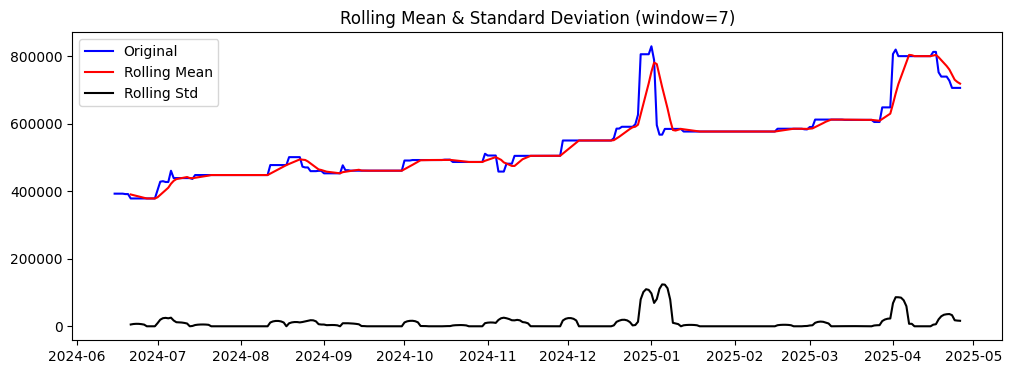

Results of Dickey-Fuller Test:
Test Statistic                  -1.311752
p-value                          0.623779
#Lags Used                       6.000000
Number of Observations Used    309.000000
Critical Value (1%)             -3.451691
Critical Value (5%)             -2.870939
Critical Value (10%)            -2.571778
dtype: float64

Is the series stationary? No (p-value: 0.6238)

Starting Training...
Training Finished.
                                      SARIMAX Results                                      
Dep. Variable:                     total_price_166   No. Observations:                  316
Model:             SARIMAX(1, 0, 0)x(1, 1, [1], 7)   Log Likelihood               -3461.558
Date:                             Mon, 05 May 2025   AIC                           6931.116
Time:                                     17:31:33   BIC                           6945.945
Sample:                                 06-15-2024   HQIC                          6937.050
                   

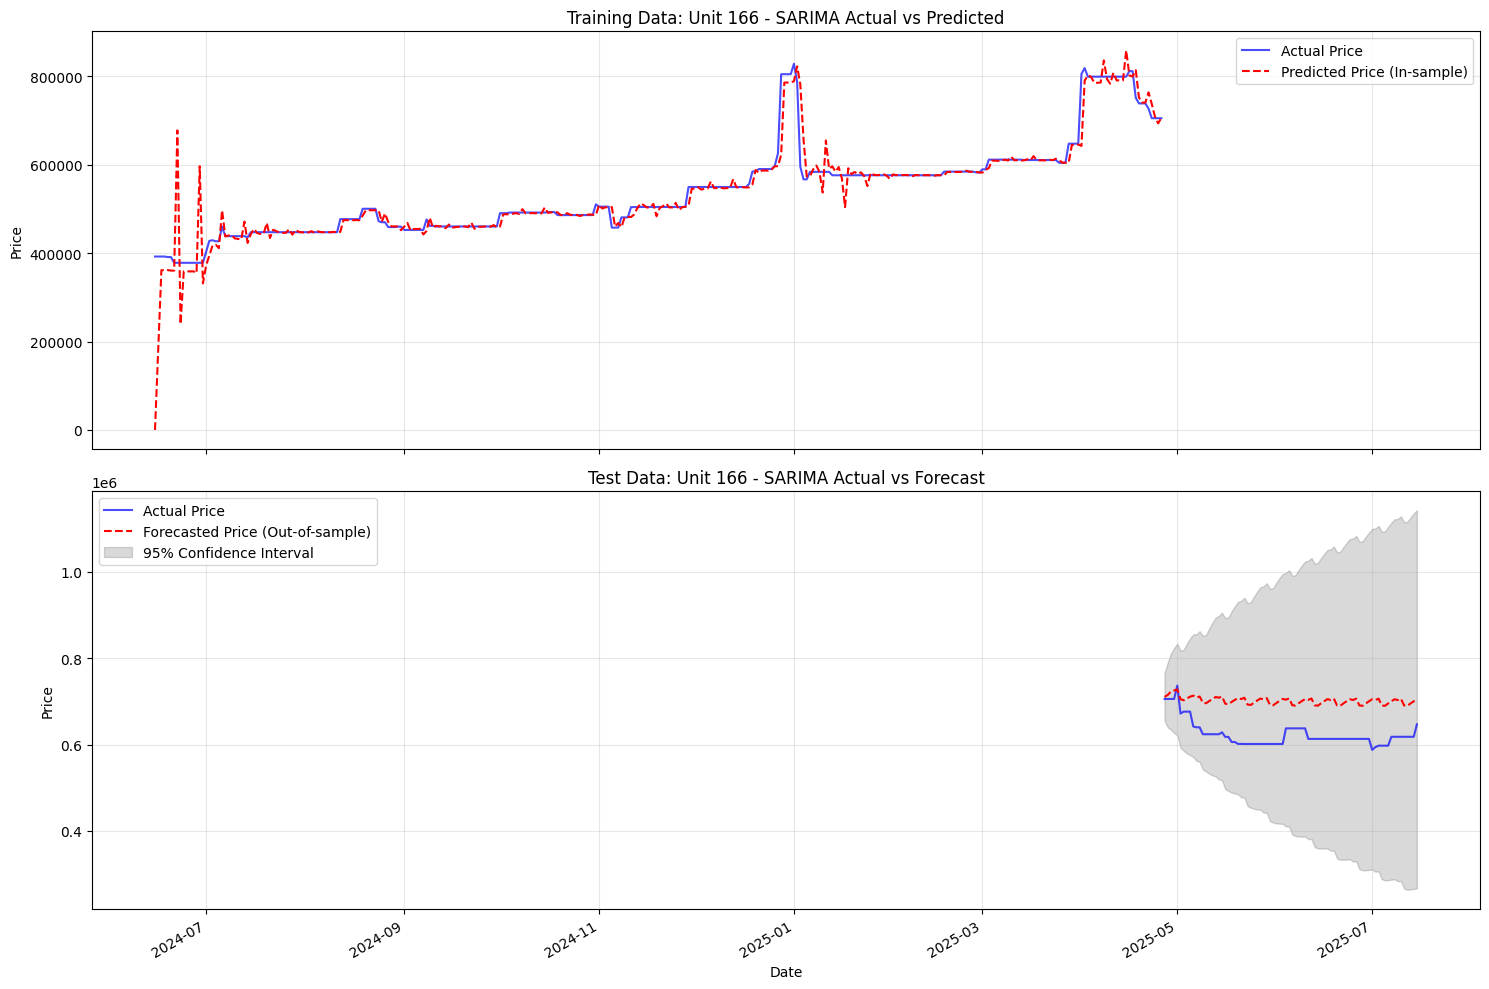

Plotting predictions on the full dataset...


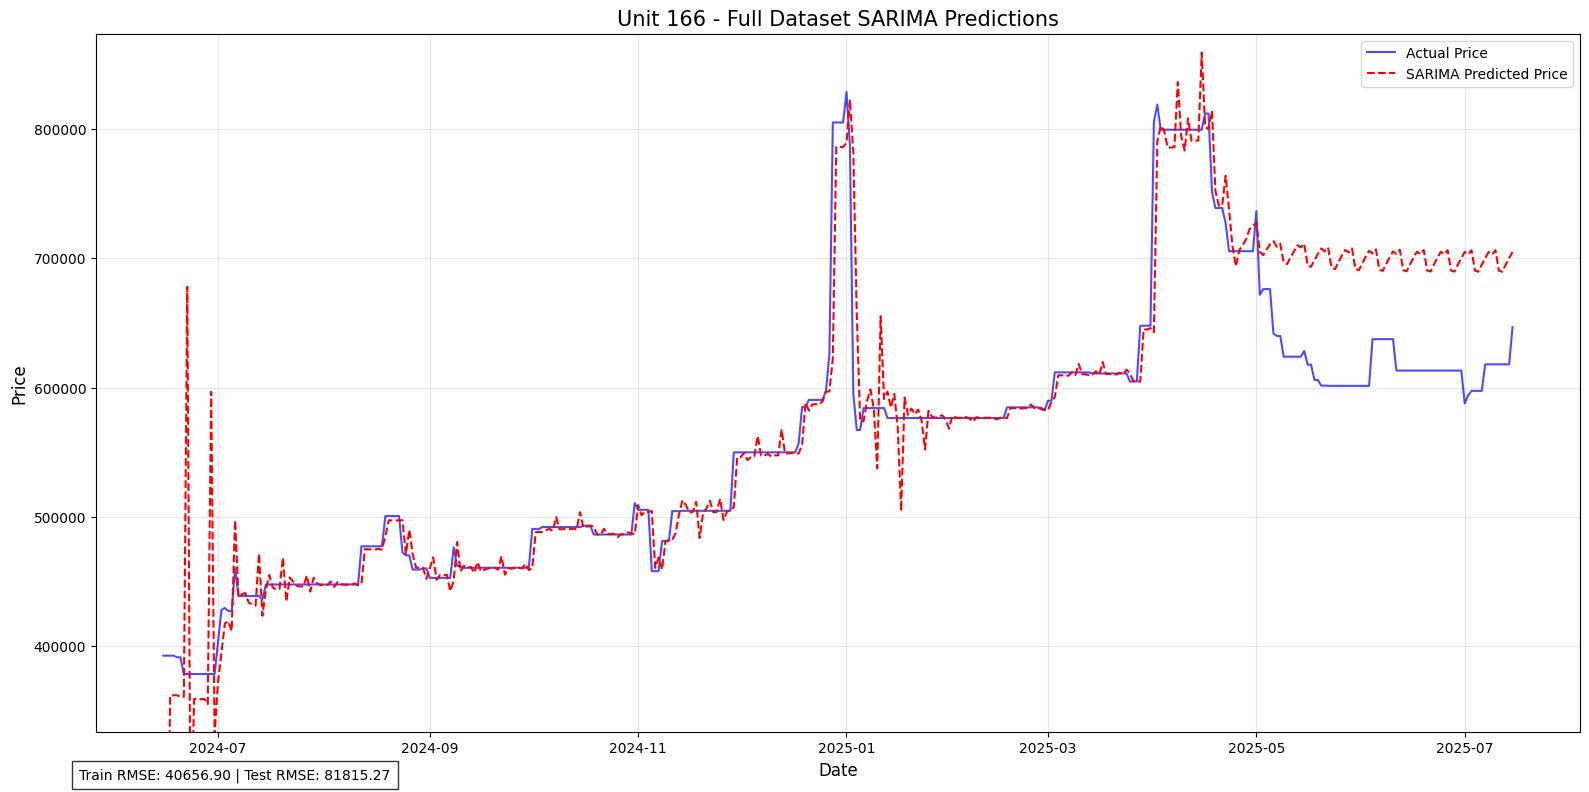


Pipeline finished for Unit 166.
--- End SARIMA Pipeline ---


In [26]:
sarima_results_166 = run_sarima_pipeline(
    df_166,
    '166',
    test_size=0.2,
)

--- Starting SARIMA Pipeline for Unit 167 ---

[Step 1/3] Splitting data with test_size=0.2...
split complete. Test size: 0.20
Training set range: 2024-06-15 00:00:00 to 2025-04-26 00:00:00 (316 samples)
Testing set range: 2025-04-27 00:00:00 to 2025-07-15 00:00:00 (80 samples)

[Step 2/3] Training and evaluating SARIMA model...

Training SARIMA model for target: total_price_167
Order: (1, 0, 0), Seasonal Order: (1, 1, 1, 7)
Training set size: 316 samples (2024-06-15 00:00:00 to 2025-04-26 00:00:00)
Testing set size: 80 samples (2025-04-27 00:00:00 to 2025-07-15 00:00:00)

Checking stationarity of training data...


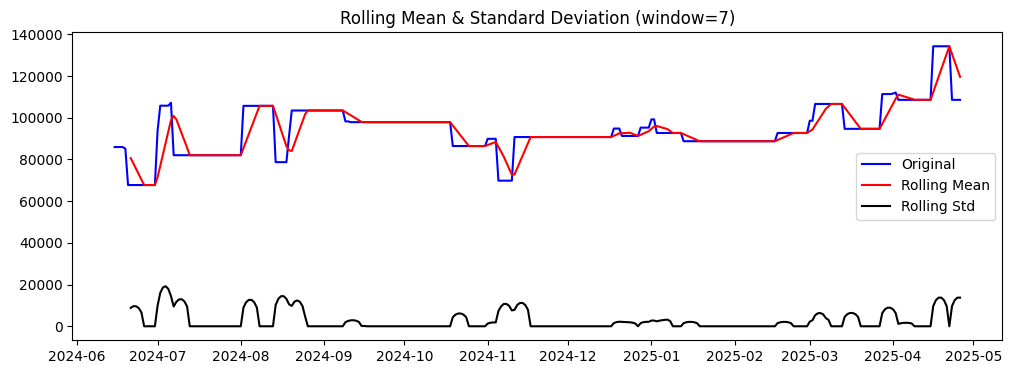

Results of Dickey-Fuller Test:
Test Statistic                  -2.087993
p-value                          0.249370
#Lags Used                      12.000000
Number of Observations Used    303.000000
Critical Value (1%)             -3.452118
Critical Value (5%)             -2.871127
Critical Value (10%)            -2.571878
dtype: float64

Is the series stationary? No (p-value: 0.2494)

Starting Training...
Training Finished.
                                      SARIMAX Results                                      
Dep. Variable:                     total_price_167   No. Observations:                  316
Model:             SARIMAX(1, 0, 0)x(1, 1, [1], 7)   Log Likelihood               -3010.864
Date:                             Mon, 05 May 2025   AIC                           6029.727
Time:                                     17:32:45   BIC                           6044.556
Sample:                                 06-15-2024   HQIC                          6035.661
                   

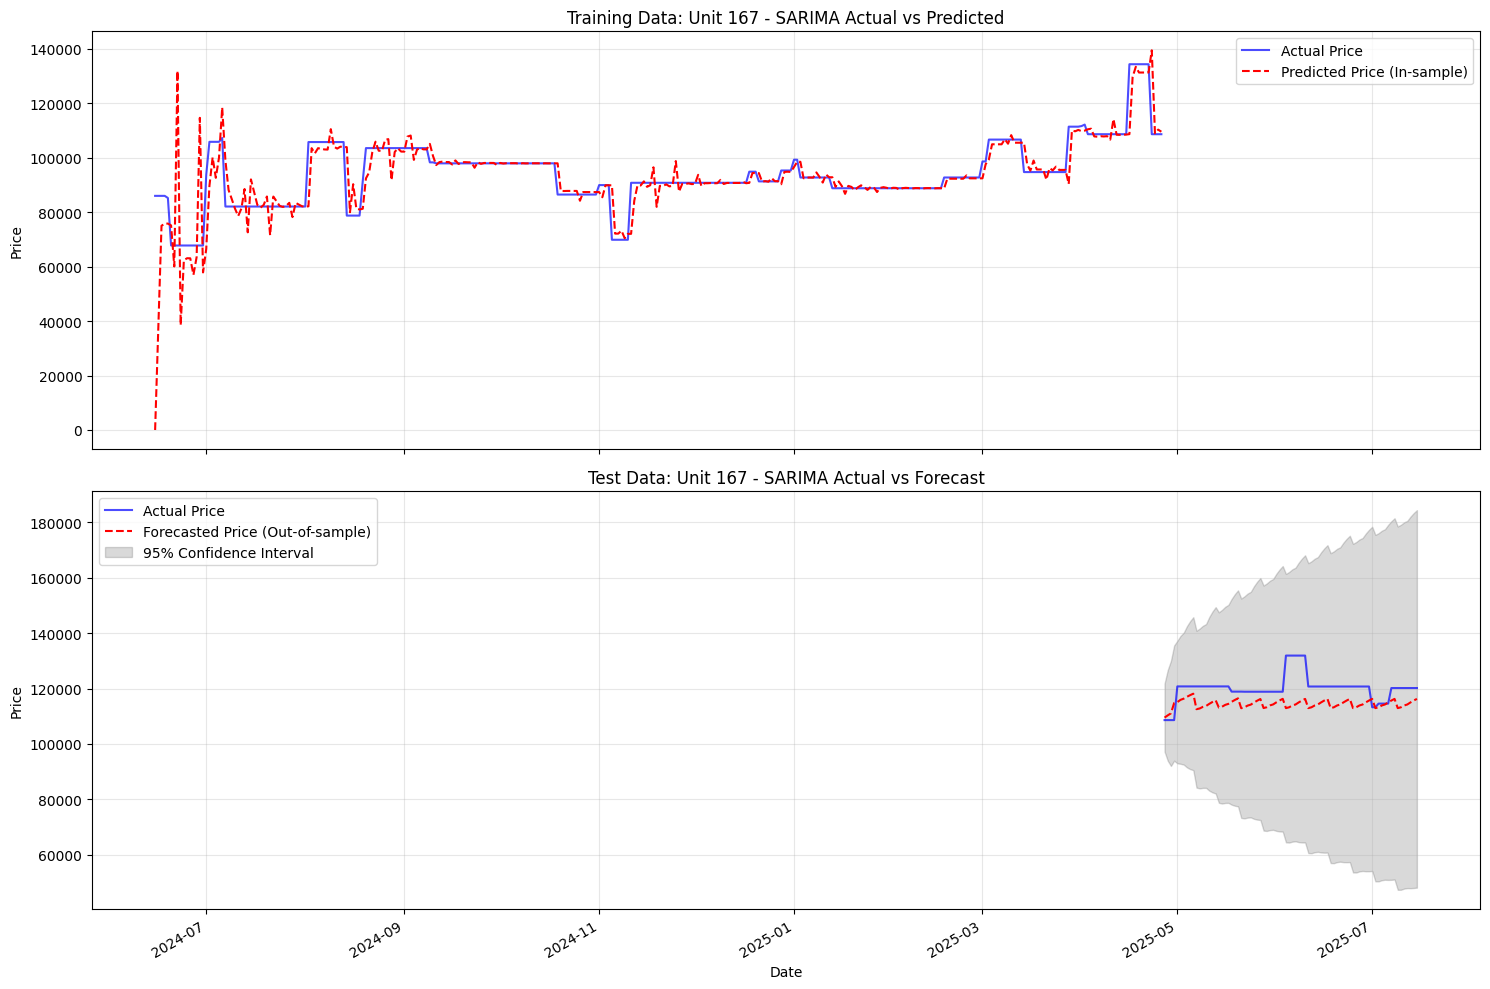

Plotting predictions on the full dataset...


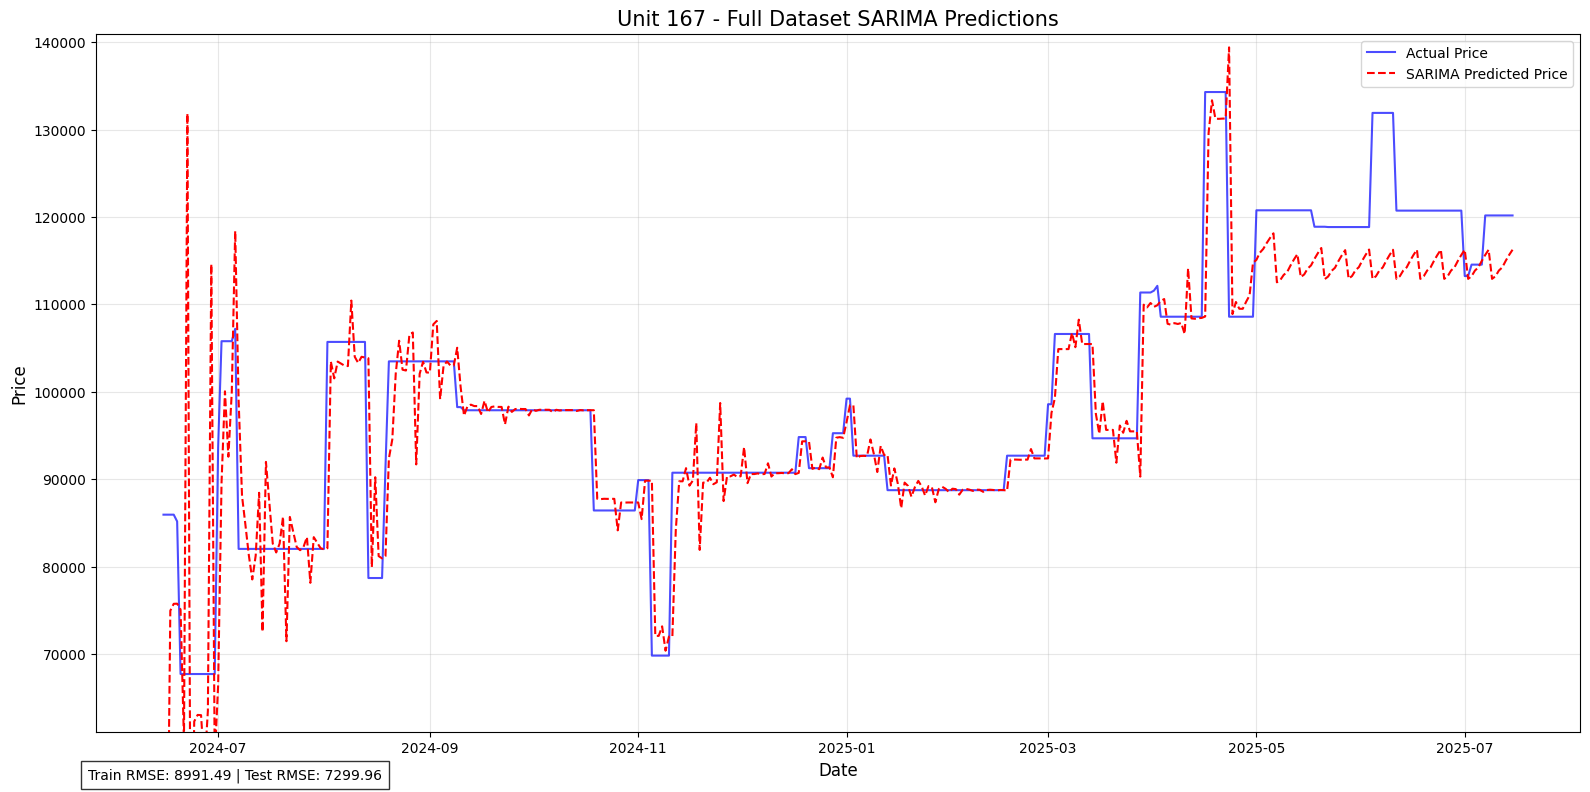


Pipeline finished for Unit 167.
--- End SARIMA Pipeline ---


In [27]:
sarima_results_167 = run_sarima_pipeline(
    df_167,
    '167',
    test_size=0.2,
)

In [28]:
def save_sarima_model(sarima_results, folder_path, model_name):
    """
    Save a trained SARIMA model using pickle to a specified folder path.
    """
    if not os.path.exists(folder_path):
        os.makedirs(folder_path)
        print(f"Created directory: {folder_path}")
    
    model_file_path = os.path.join(folder_path, f"{model_name}.pkl")
    
    model_fit = sarima_results.get('model_fit')
    if model_fit is None:
        print("Error: No model_fit found in the sarima_results dictionary")
        return None
    
    try:
        with open(model_file_path, 'wb') as f:
            pickle.dump(model_fit, f)
        print(f"Model successfully saved to {model_file_path}")
        
        params_path = os.path.join(folder_path, f"{model_name}_params.json")
        params = {
            'order': sarima_results.get('order'),
            'seasonal_order': sarima_results.get('seasonal_order'),
            'metrics': sarima_results.get('metrics', {})
        }
        
        with open(params_path, 'w') as f:
            json.dump(params, f, indent=4)
        print(f"Model parameters saved to {params_path}")
        
        return model_file_path
    except Exception as e:
        print(f"Error saving model: {e}")
        return None

In [29]:
save_sarima_model(sarima_results_166, '../TrainedModels/SARIMAModels', 'sarima_model_166')
save_sarima_model(sarima_results_167, '../TrainedModels/SARIMAModels', 'sarima_model_167')

Created directory: ../TrainedModels/SARIMAModels
Model successfully saved to ../TrainedModels/SARIMAModels\sarima_model_166.pkl
Model parameters saved to ../TrainedModels/SARIMAModels\sarima_model_166_params.json
Model successfully saved to ../TrainedModels/SARIMAModels\sarima_model_167.pkl
Model parameters saved to ../TrainedModels/SARIMAModels\sarima_model_167_params.json


'../TrainedModels/SARIMAModels\\sarima_model_167.pkl'

In [83]:
def load_sarima_model(folder_path, model_name):
    """
    Load a pickled SARIMA model (SARIMAXResultsWrapper) from a specified folder path.

    Args:
        folder_path (str): The directory where the model is saved.
        model_name (str): The name of the model file (without .pkl extension).
    """
    model_file_path = os.path.join(folder_path, f"{model_name}.pkl")
    
    if not os.path.exists(model_file_path):
        print(f"Error: SARIMA model file not found at {model_file_path}")
        return None
    
    try:
        with open(model_file_path, 'rb') as f:
            model_fit = pickle.load(f)
        print(f"SARIMA model successfully loaded from {model_file_path}")
        return model_fit
    except Exception as e:
        print(f"Error loading SARIMA model: {e}")
        return None

In [84]:
loaded_sarima_model_166 = load_sarima_model('../TrainedModels/SARIMAModels', 'sarima_model_166')
loaded_sarima_model_167 = load_sarima_model('../TrainedModels/SARIMAModels', 'sarima_model_167')

SARIMA model successfully loaded from ../TrainedModels/SARIMAModels\sarima_model_166.pkl
SARIMA model successfully loaded from ../TrainedModels/SARIMAModels\sarima_model_167.pkl


In [ ]:
def predict_single_date_sarima_model(model_fit, target_date_str):
    """
    Predicts the total_price for a single future date using a loaded SARIMA model.

    Args:
        model_fit (statsmodels.tsa.statespace.sarimax.SARIMAXResultsWrapper): The loaded SARIMA model.
        target_date_str (str): The target date for prediction in 'YYYY-MM-DD' format.
    """
    if model_fit is None:
        print("Error: The SARIMA model provided is None.")
        return None

    try:
        target_date = pd.to_datetime(target_date_str)
    except ValueError:
        print(f"Error: Invalid target_date_str format: {target_date_str}. Please use 'YYYY-MM-DD'.")
        return None

    print(f"\nPredicting with SARIMA for date: {target_date_str}")

    try:
        prediction_series = model_fit.predict(start=target_date, end=target_date)
        
        if prediction_series.empty:
            print(f"Error: SARIMA prediction for {target_date_str} resulted in an empty series.")
            return None
            
        predicted_value = prediction_series.iloc[0]
        print(f"Predicted price for {target_date_str} (SARIMA): {predicted_value:.2f}")
        return float(predicted_value)
        
    except Exception as e:
        print(f"Error during SARIMA prediction for {target_date_str}: {e}")
        return None

In [92]:
predict_single_date_sarima_model(loaded_sarima_model_166, '2025-04-20')


Predicting with SARIMA for date: 2025-04-20
Predicted price for 2025-04-20 (SARIMA): 740874.34


740874.3425996796